Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [262]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_default_chrom_configs

config, _ = load_default_chrom_configs()
real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Initializing N using config H.
Initializing B using timepoint 0


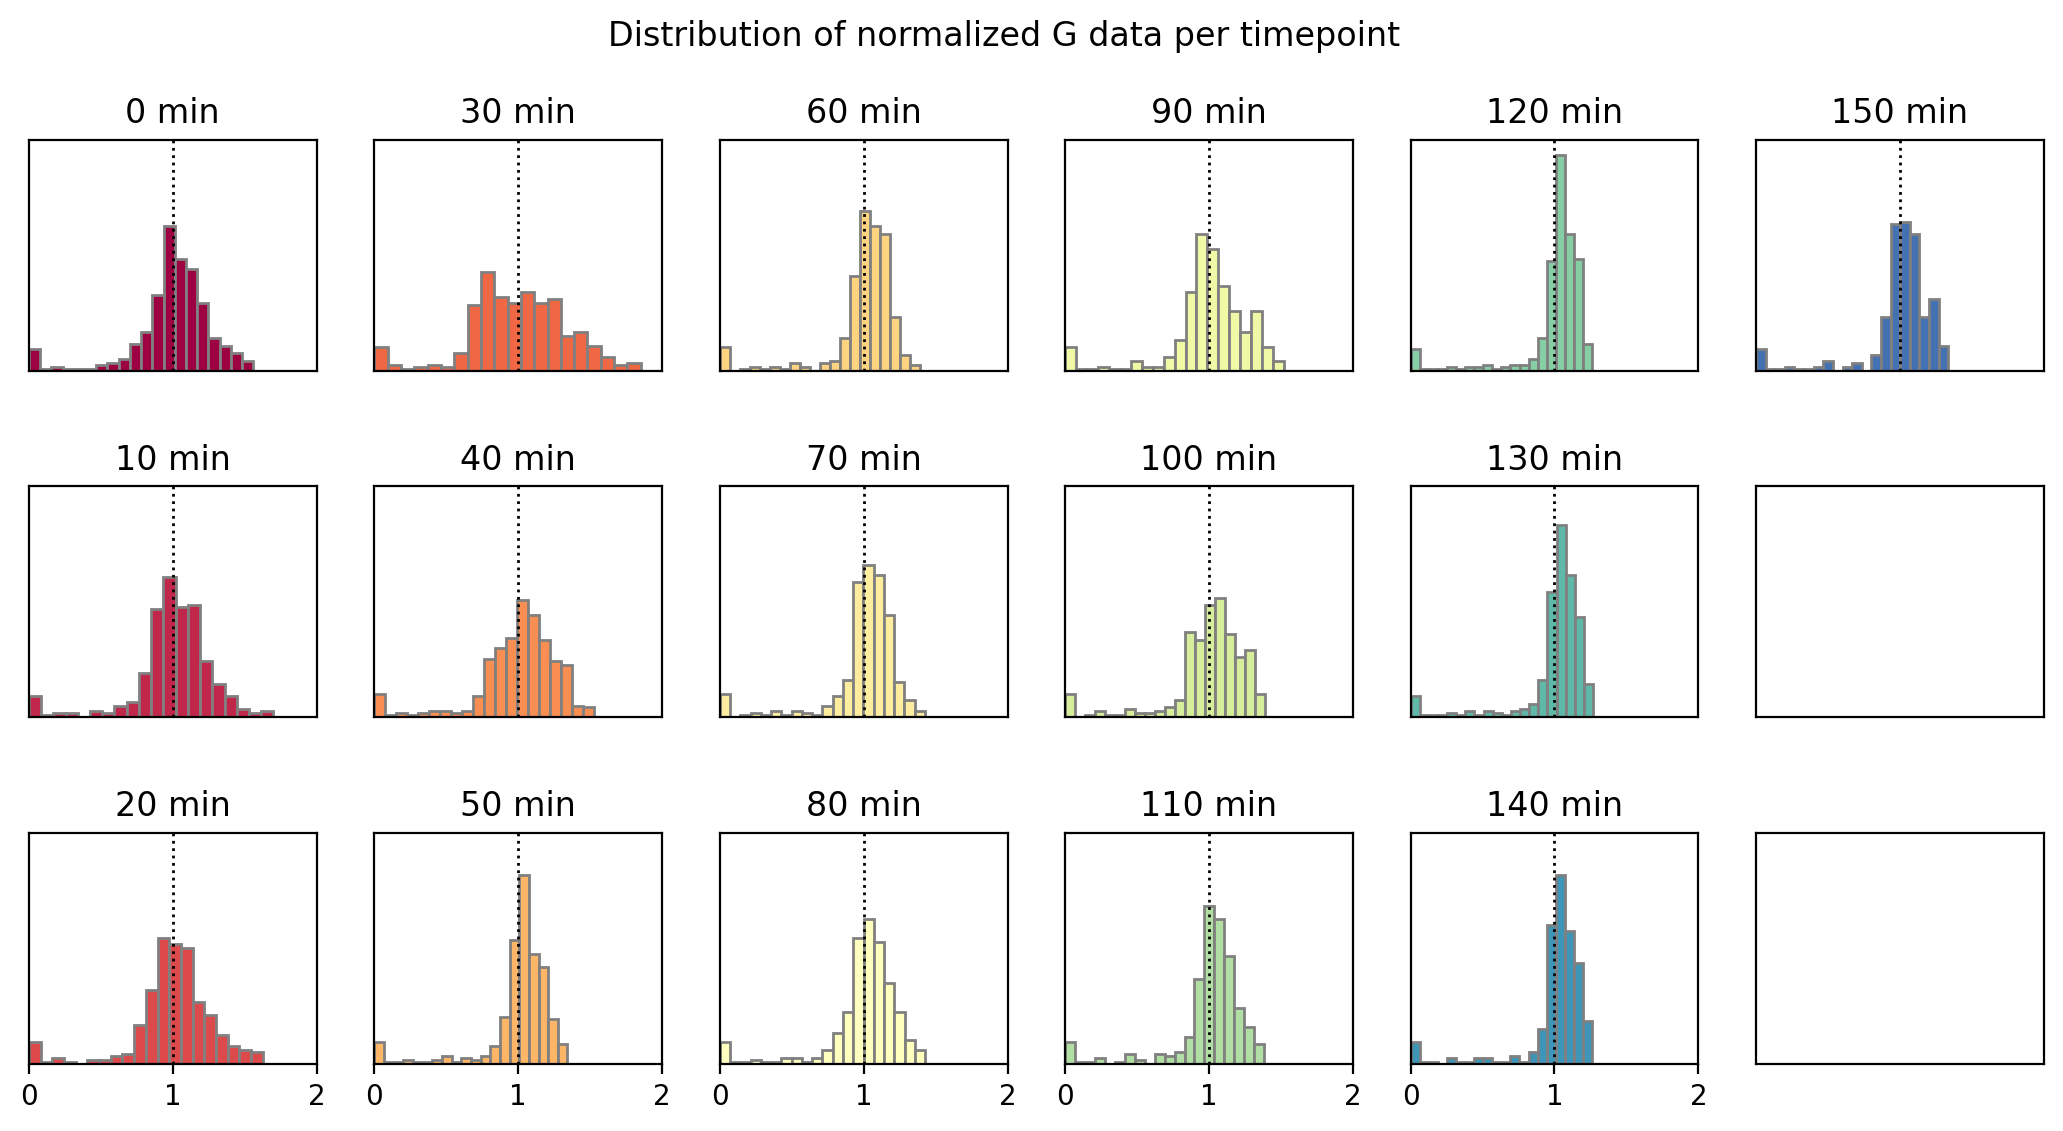

In [263]:
from src.RealDataReplication import plot_histogram_occupancies_G
plot_histogram_occupancies_G(real_deconv1.config, real_deconv1.G)

###### 

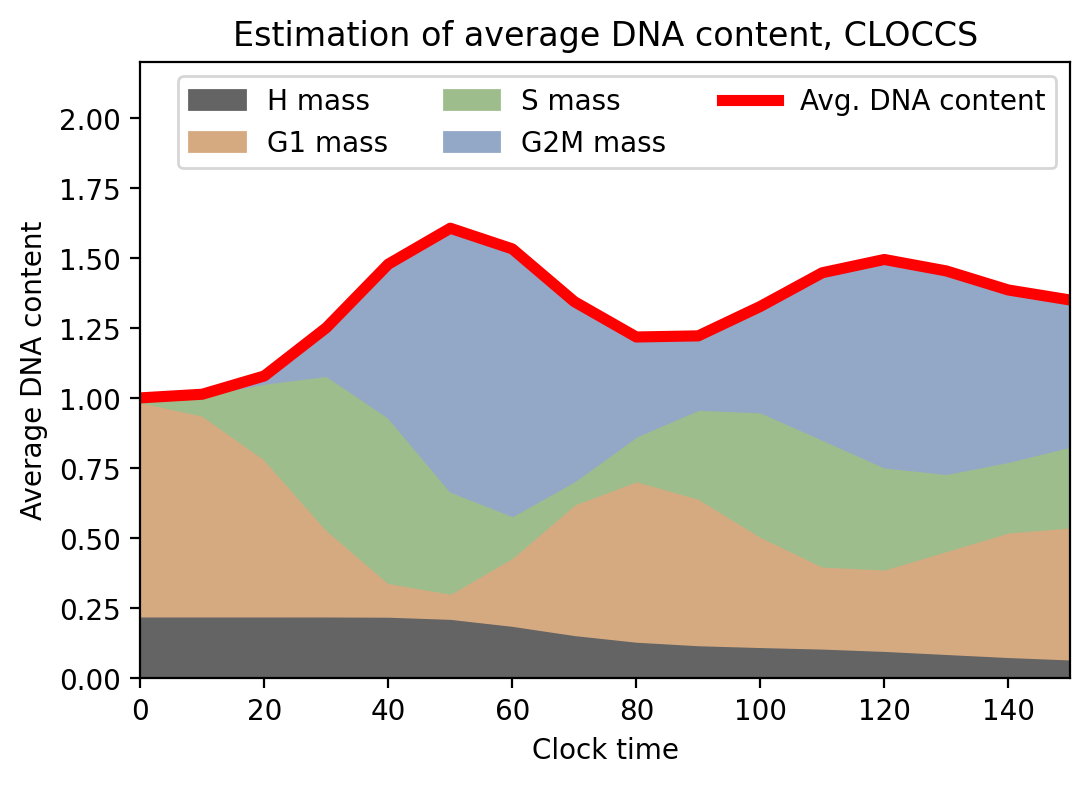

In [924]:
from src.RealDataReplication import compute_N
from src.figure_configs import save_figure_for_paper

_ = compute_N(real_deconv1.config, plot=True)
save_figure_for_paper(
    'output/figures/Replication_Deconvolution/Average_DNA_content_rep1.png')

In [265]:
real_deconv1.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:04.174
100/368 - 00:00:08.241
150/368 - 00:00:12.316
200/368 - 00:00:16.692
250/368 - 00:00:20.814
300/368 - 00:00:24.910
350/368 - 00:00:28.939


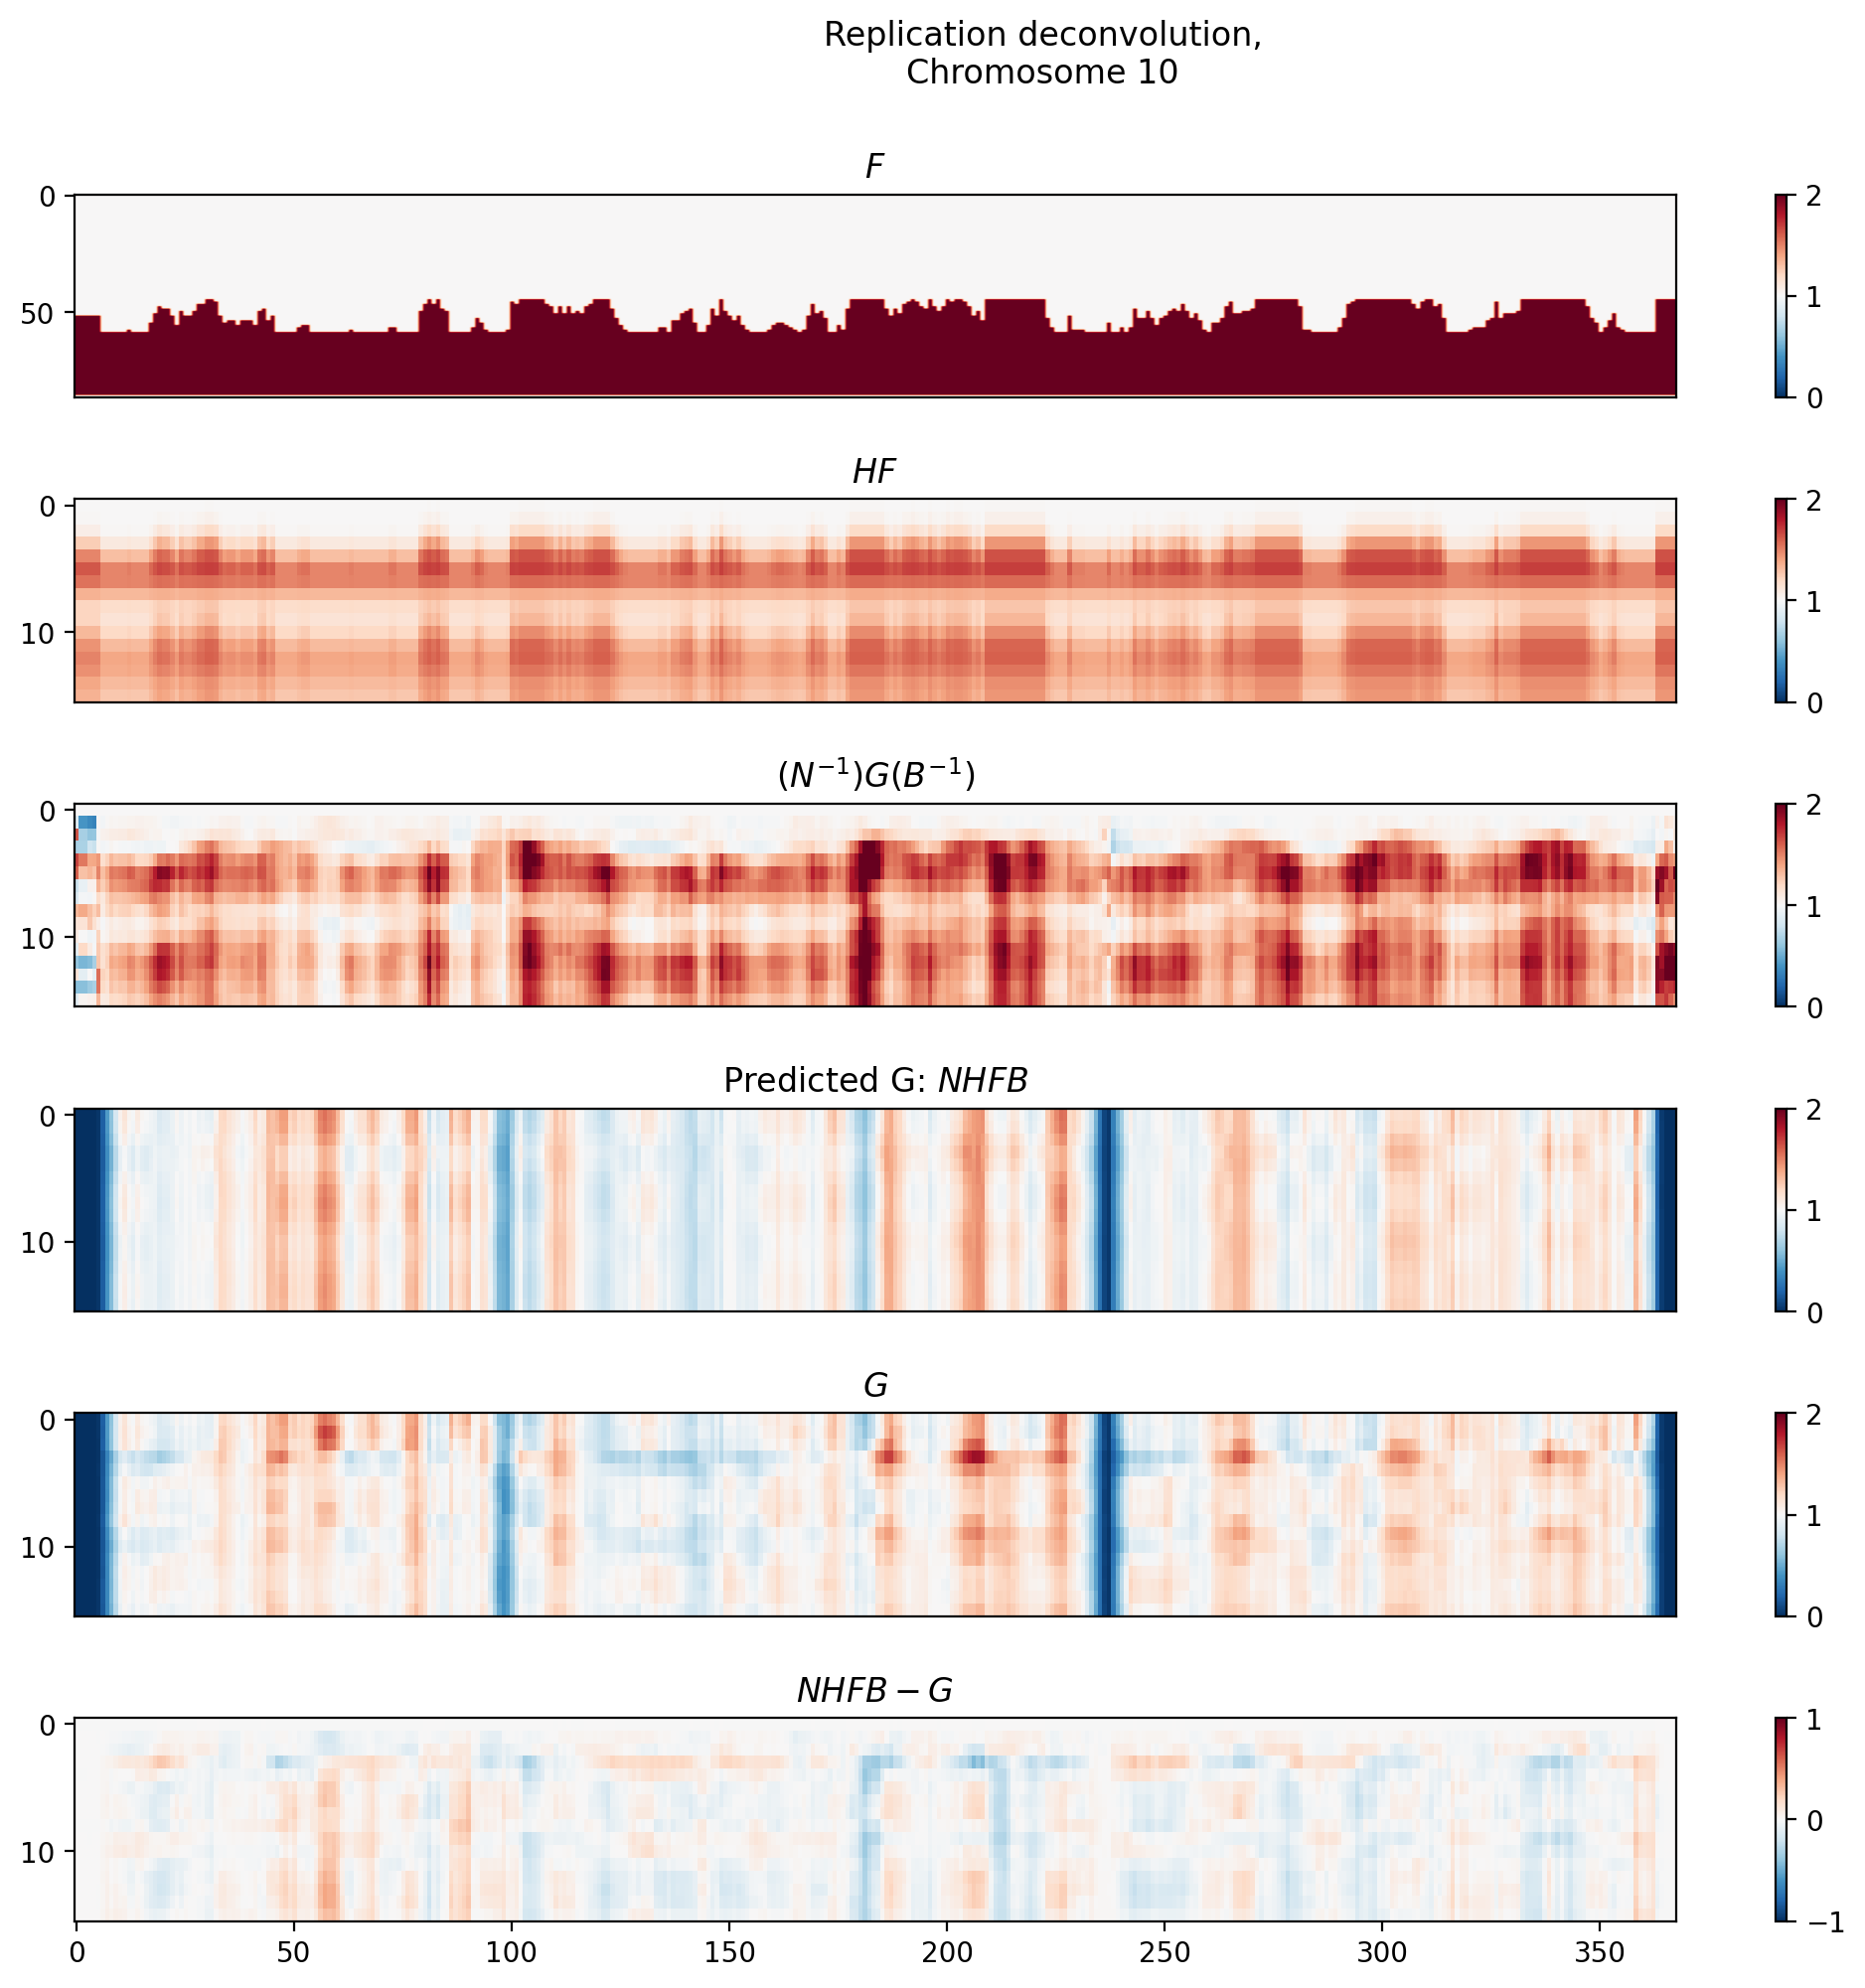

In [266]:
real_deconv1.plot_heatmaps()

In [94]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs(longer_file=False)
real_deconv_combined = RealDataReplicationDeconvolution(configs=[config1, config2], 
    deconvolve_combined=True)


todo: Copy correction is not in place
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0


In [95]:
real_deconv_combined.deconvolve()

0/368 - 00:00:00.000
50/368 - 00:00:05.146
100/368 - 00:00:09.960
150/368 - 00:00:15.091
200/368 - 00:00:19.747
250/368 - 00:00:24.381
300/368 - 00:00:29.201
350/368 - 00:00:33.910


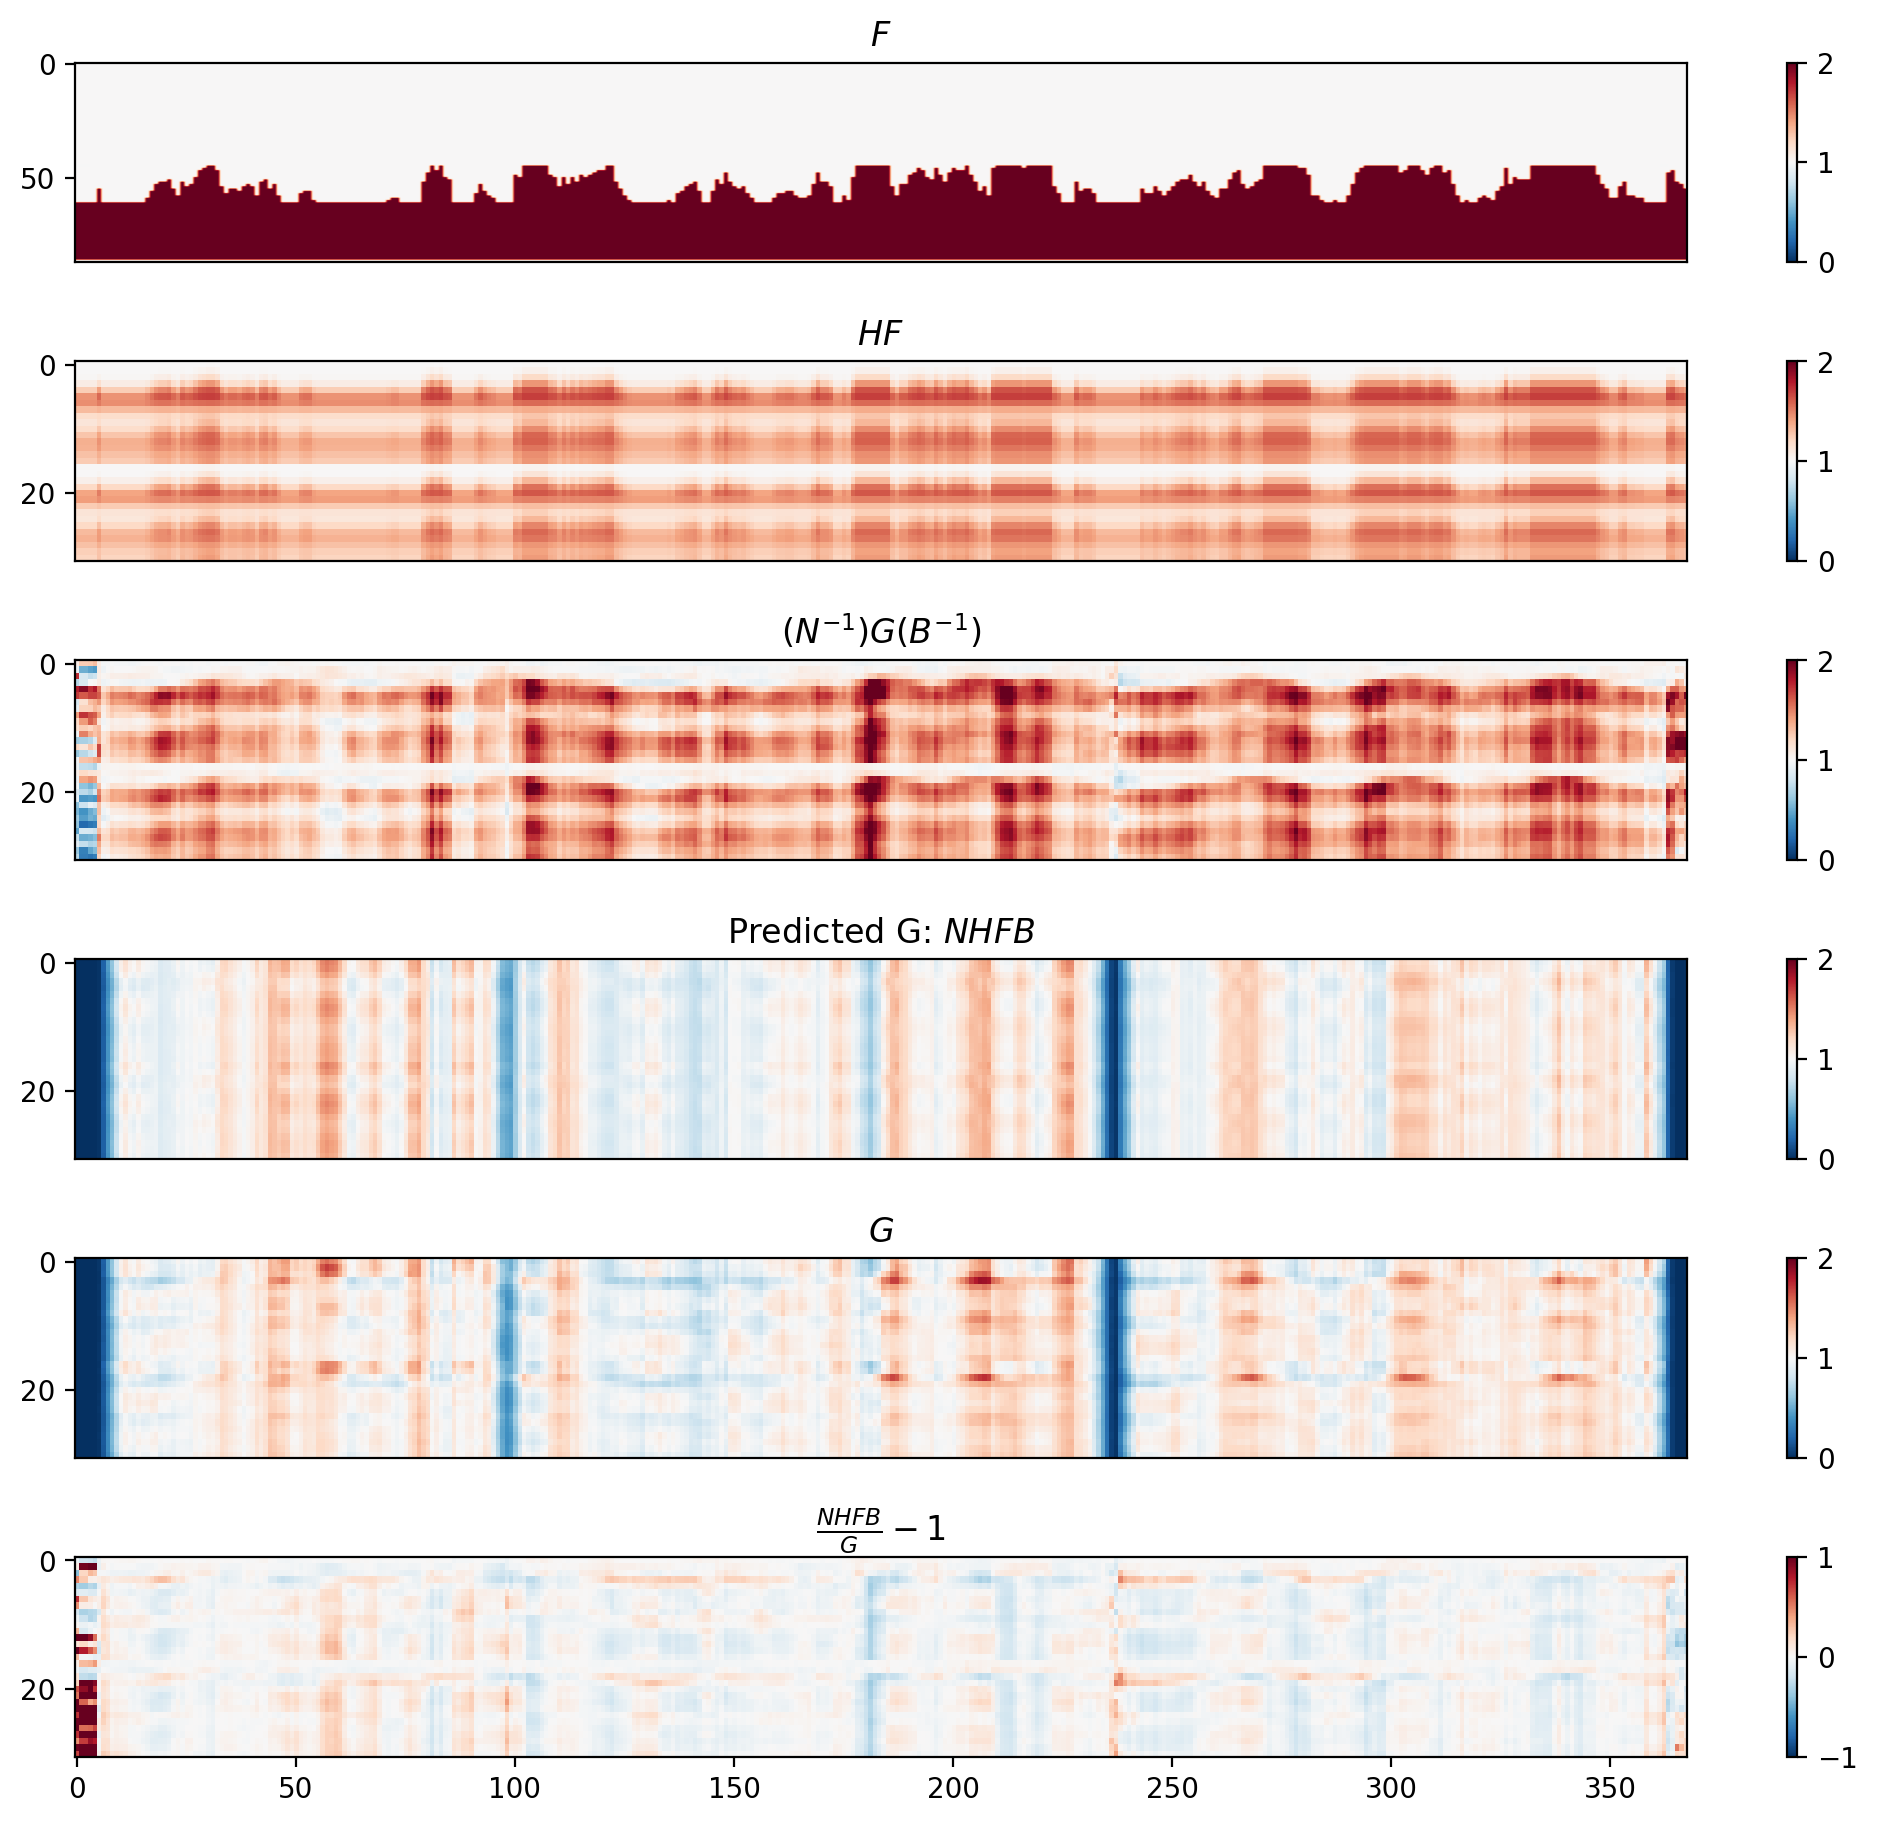

In [96]:
real_deconv_combined.plot_heatmaps()

Text(0.5, 1.0, 'Average DNA (clock time)')

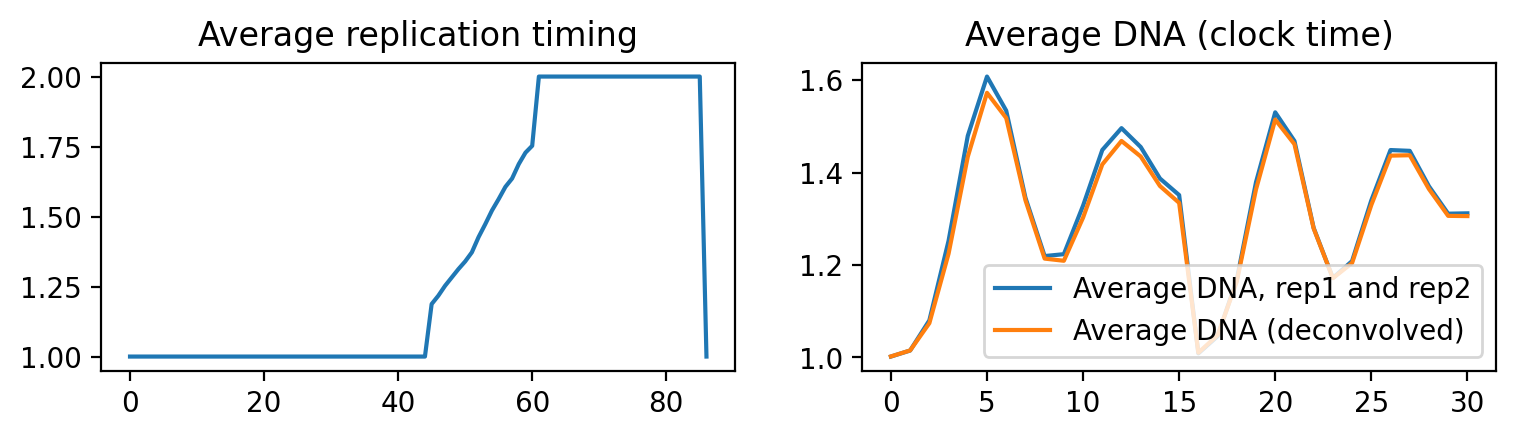

In [97]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.plot(real_deconv_combined.F.mean(axis=1), label="Mean F")
plt.title("Average replication timing")

plt.subplot(1, 2, 2)
plt.plot(real_deconv_combined.average_DNA, label="Average DNA, rep1 and rep2")
plt.plot(real_deconv_combined.H@real_deconv_combined.F.mean(axis=1), 
    label="Average DNA (deconvolved)")
plt.legend()
plt.title("Average DNA (clock time)")

In [112]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr10_combined.csv
Saved to: data/copy_correction//F_chr10_combined.csv


In [113]:
real_deconv_combined = RealDataReplicationDeconvolution(configs=[config1, config2], 
    replicate=1, deconvolve_combined=True, chr=16)

Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0


In [114]:
real_deconv_combined.deconvolve()

0/470 - 00:00:00.000
50/470 - 00:00:04.775
100/470 - 00:00:09.615
150/470 - 00:00:14.213
200/470 - 00:00:19.095
250/470 - 00:00:23.997
300/470 - 00:00:28.422
350/470 - 00:00:33.213
400/470 - 00:00:37.892
450/470 - 00:00:43.015


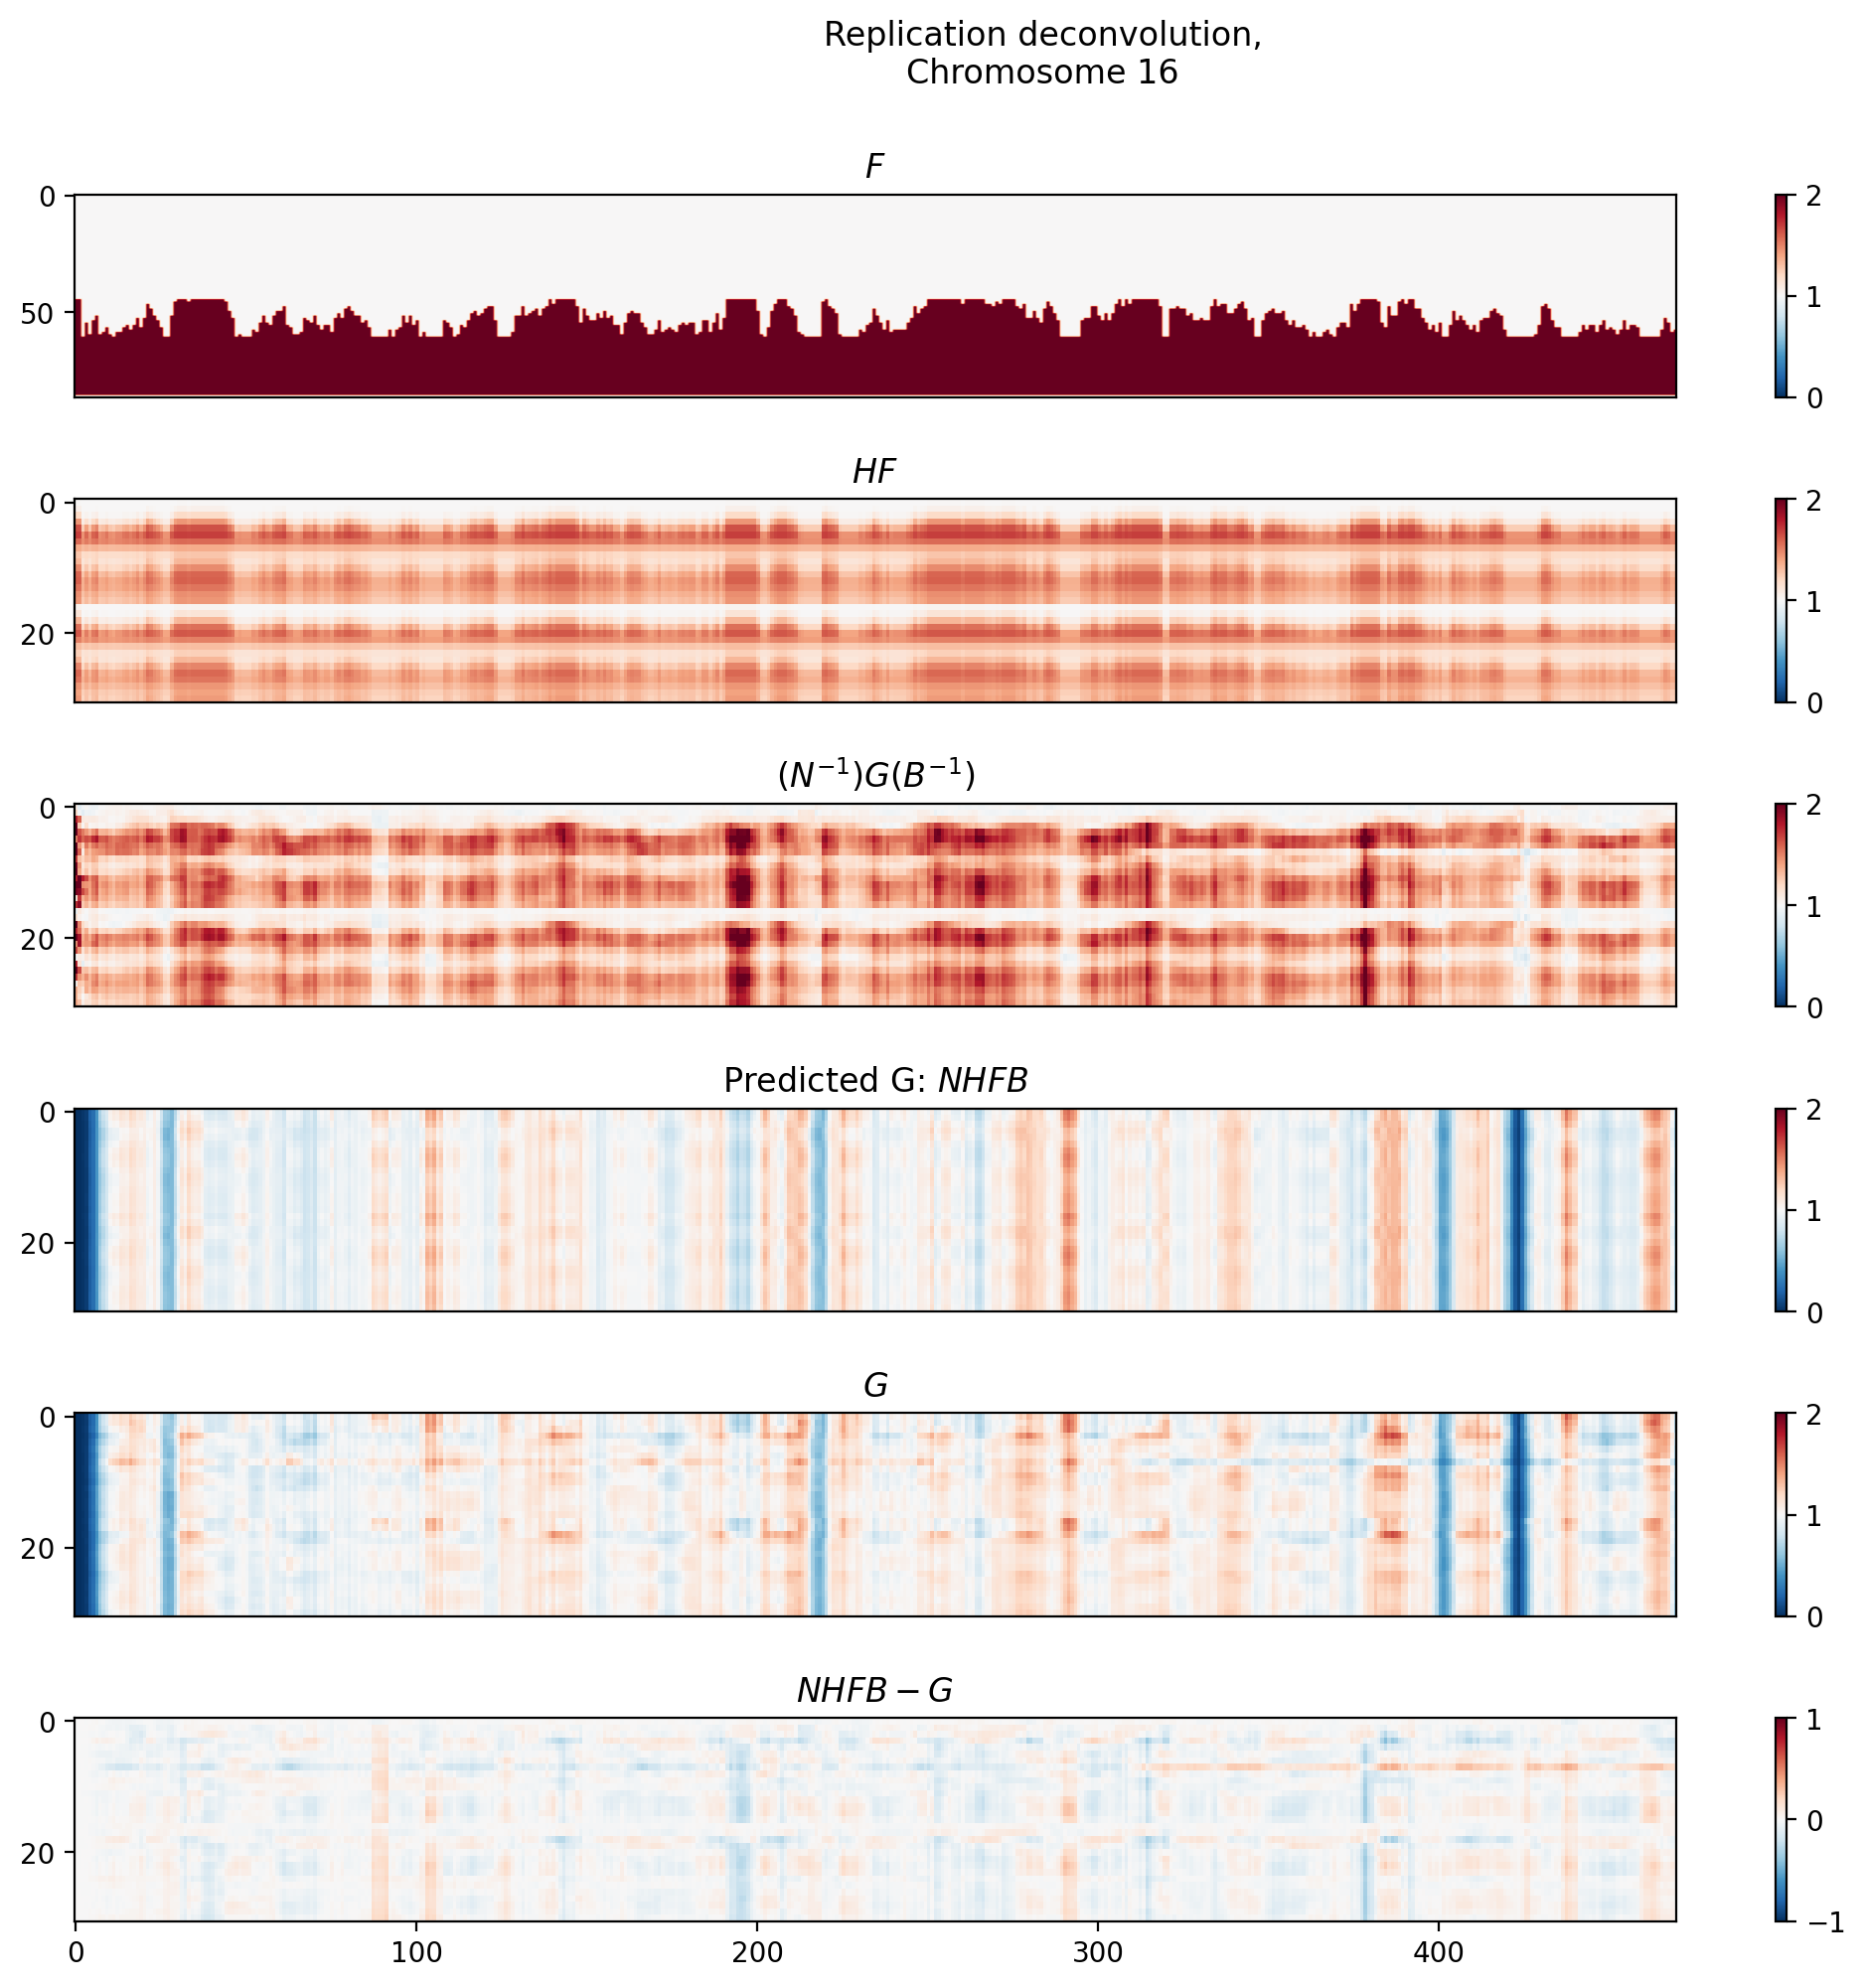

In [197]:
real_deconv_combined.plot_heatmaps()

In [115]:
real_deconv_combined.save_replication_deconvolution()

Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr16_combined.csv
Saved to: data/copy_correction//F_chr16_combined.csv


In [130]:
from src.timer import Timer

timer = Timer()
for chrom in range(1, 17):
    print("Chromosome", chrom)
    real_deconv_combined = RealDataReplicationDeconvolution(configs=[config1, config2], 
        deconvolve_combined=True, chr=chrom)
    real_deconv_combined.deconvolve()
    real_deconv_combined.save_replication_deconvolution()
    timer.print_time()


Chromosome 1
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/111 - 00:00:00.000
50/111 - 00:00:05.388
100/111 - 00:00:12.307
Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr1_combined.csv
Saved to: data/copy_correction//F_chr1_combined.csv
00:00:19.383
Chromosome 2
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/402 - 00:00:00.000
50/402 - 00:00:04.603
100/402 - 00:00:09.060
150/402 - 00:00:13.567
200/402 - 00:00:18.152
250/402 - 00:00:22.835
300/402 - 00:00:27.450
350/402 - 00:00:32.191
400/402 - 00:00:36.865
Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: dat

Chromosome 15
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/541 - 00:00:00.000
50/541 - 00:00:04.674
100/541 - 00:00:09.437
150/541 - 00:00:13.951
200/541 - 00:00:18.737
250/541 - 00:00:24.115
300/541 - 00:00:28.975
350/541 - 00:00:33.917
400/541 - 00:00:38.706
450/541 - 00:00:43.500
500/541 - 00:00:48.165
Creating directory: data/copy_correction/...Directory exists. Skipping.
Saved to: data/copy_correction//N_combined.npy
Saved to: data/copy_correction//B_chr15_combined.csv
Saved to: data/copy_correction//F_chr15_combined.csv
00:14:51.380
Chromosome 16
Setting up combined deconvolution model
Initializing N using config H.
Initializing B using timepoint 0
Initializing N using config H.
Initializing B using timepoint 0
0/470 - 00:00:00.000
50/470 - 00:00:04.832
100/470 - 00:00:09.912
150/470 - 00:00:14.430
200/470 - 00:00:19.471
250/470 - 00:00:24.467
300/470 - 00:

### Update to B

We have an idea for how the update for B can be done, there may be some oddities
in its construction. Let's start with the replicate 1 deconvolution

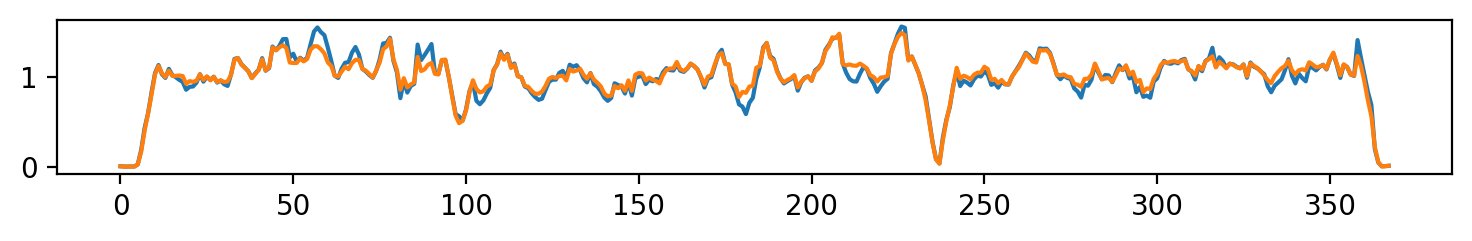

In [270]:
N, H, F, B, G = real_deconv1.N, real_deconv1.H, real_deconv1.F, real_deconv1.B, real_deconv1.G

bs = np.zeros(B.shape[0])

for j in range(B.shape[0]):
    bs[j] = G[:, j].sum() / A[:, j].sum()
    
A = N@H@F
updated_B = np.diag(bs)

plt.figure(figsize=(9, 1))
plt.plot(np.diag(B))
plt.plot(np.diag(updated_B))

In [ ]:
real_deconv1.load_replicate_data()

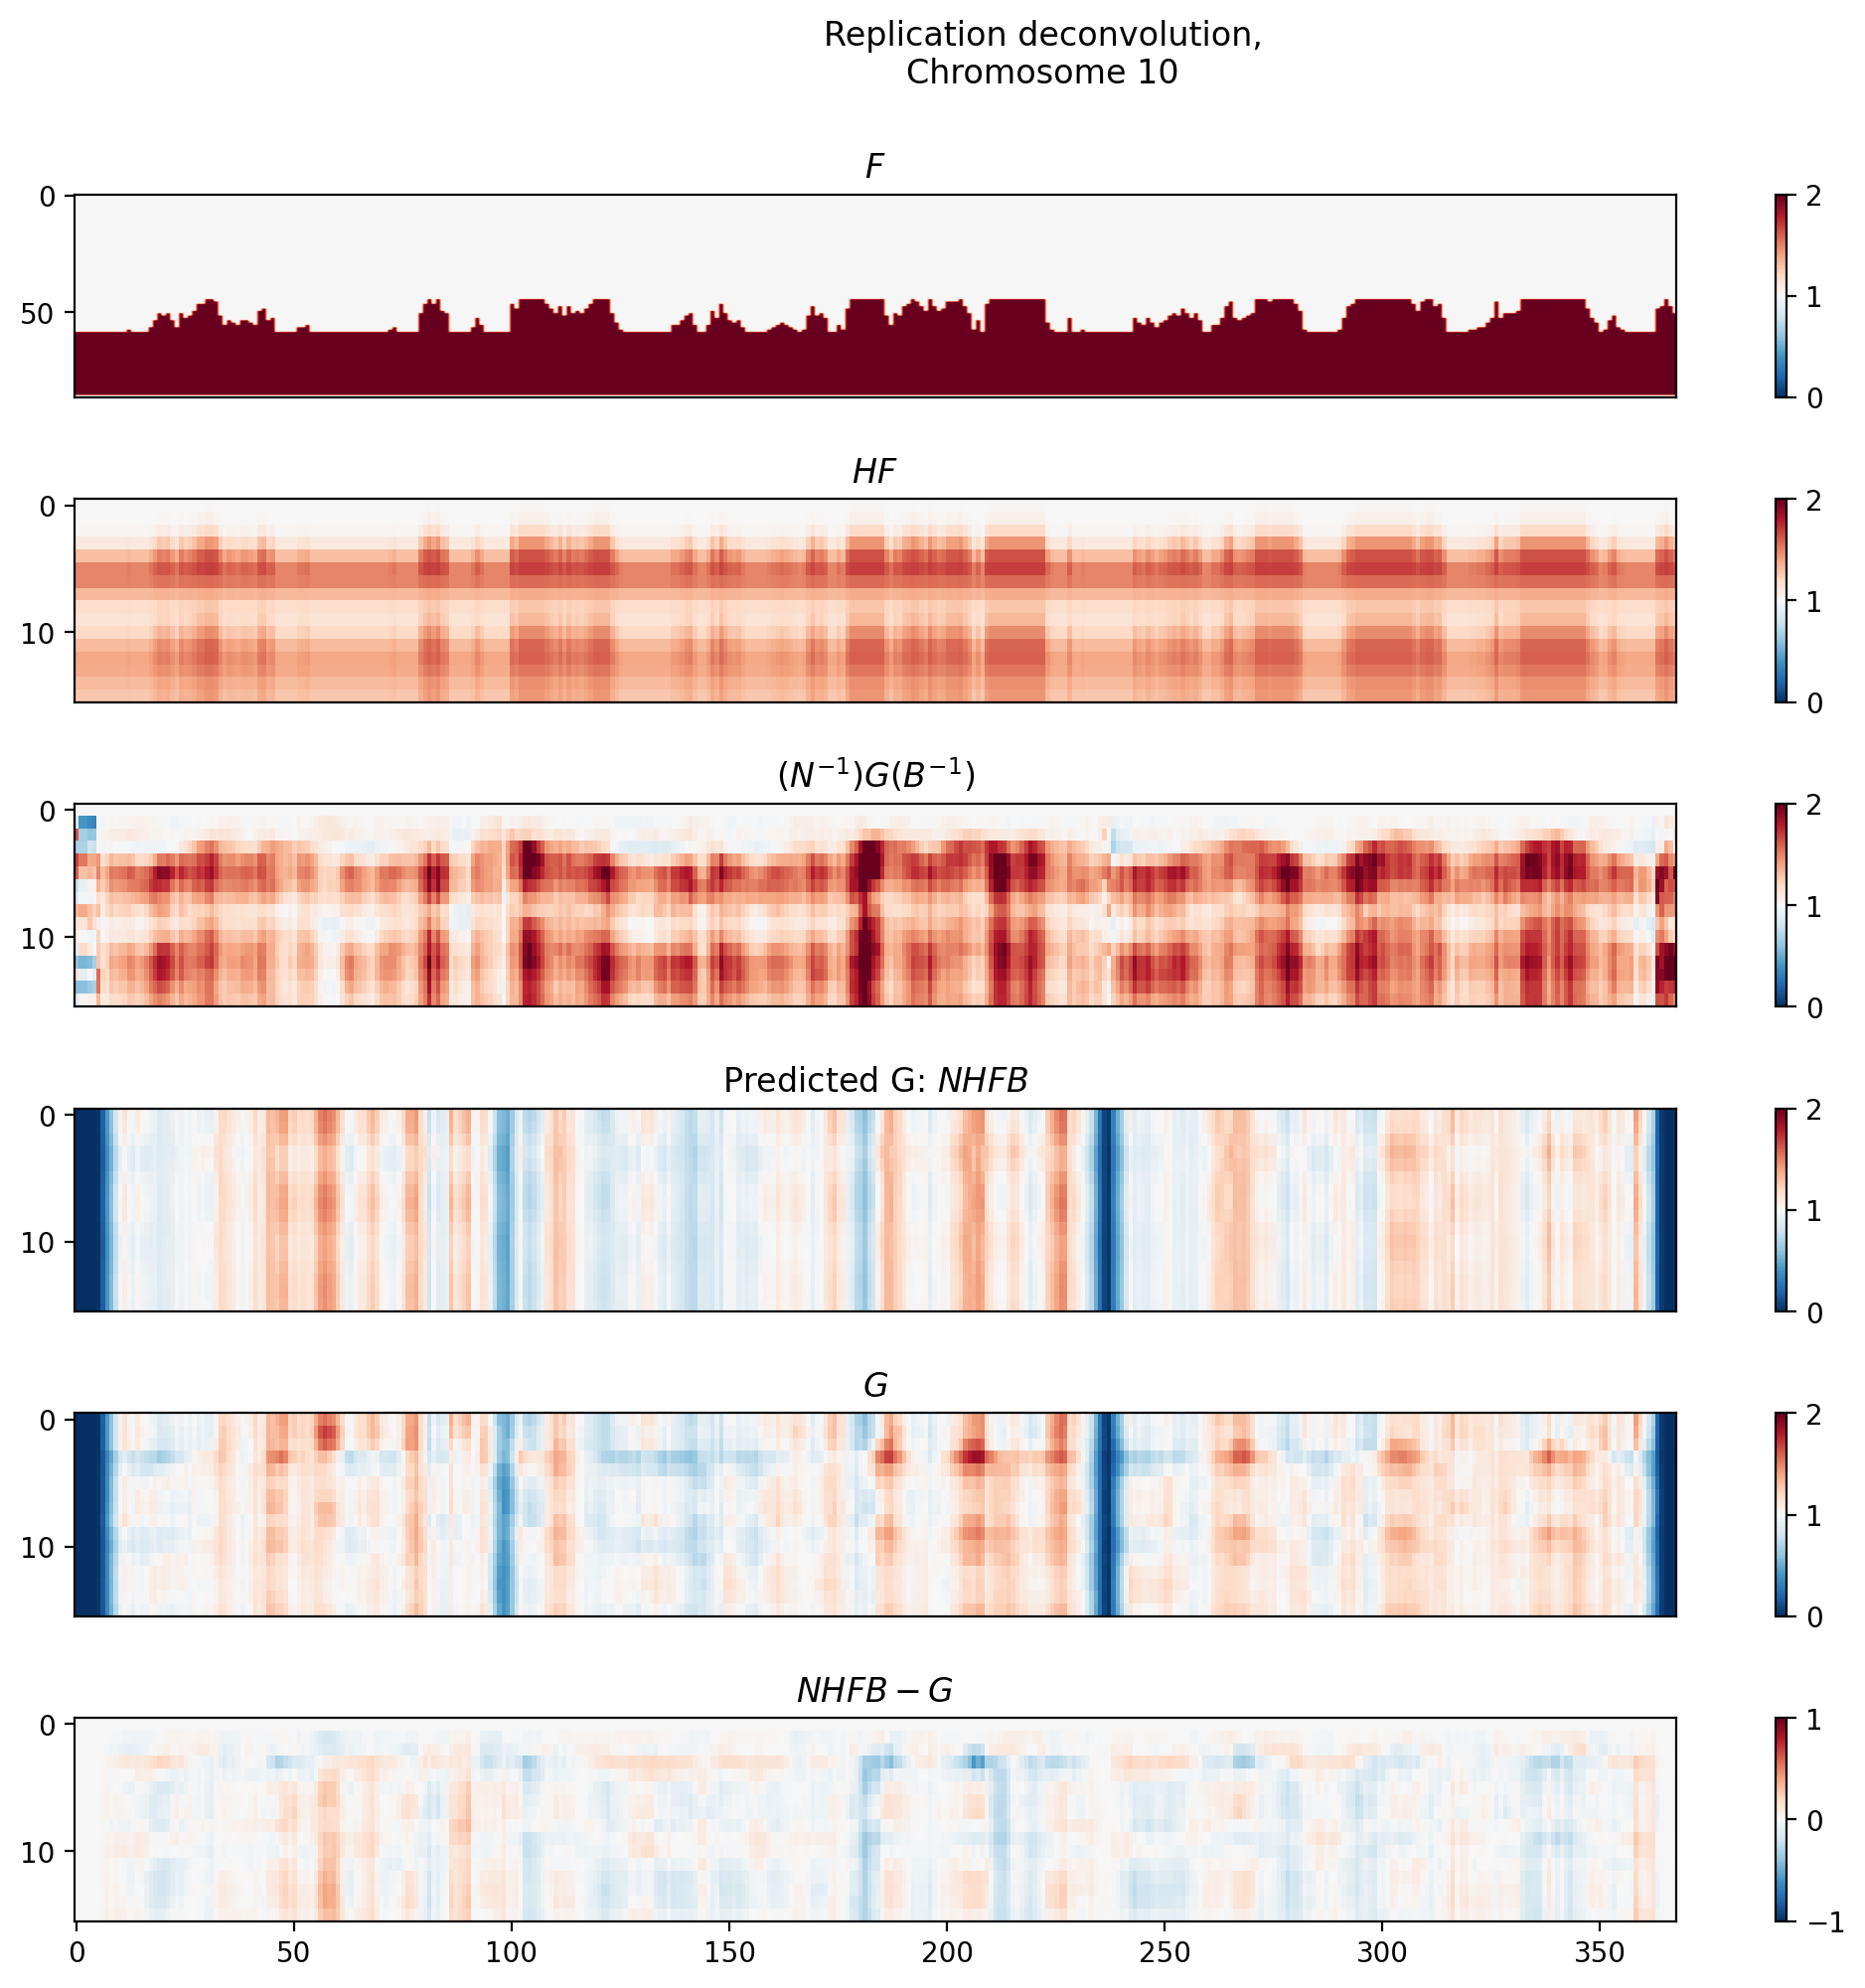

In [221]:
real_deconv1.plot_heatmaps()

In [338]:

# Tasks:
# 1. Difference model NHFB - G
# 2. Update N, update B, Plot of number iterations and residuals
# 3. Relax postG1 constraint for replication timing

# Create an interative process of updating N and B
real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=10)

Initializing N using config H.
Initializing B using timepoint 0


In [339]:
total_iterations = 10
real_deconv1.iterative_deconvolution_updates(total_iterations=total_iterations)

Iteration 0
0/368 - 00:00:00.065
50/368 - 00:00:07.850
100/368 - 00:00:15.018
150/368 - 00:00:21.089
200/368 - 00:00:27.228
250/368 - 00:00:34.129
300/368 - 00:00:40.798
350/368 - 00:00:47.500
Iteration completed 00:00:49.637, rn=0.16796766462497986
Iteration 1
0/368 - 00:00:49.701
50/368 - 00:00:56.265
100/368 - 00:01:02.971
150/368 - 00:01:08.775
200/368 - 00:01:15.088
250/368 - 00:01:21.289
300/368 - 00:01:27.196
350/368 - 00:01:33.311
Iteration completed 00:01:35.503, rn=0.11876865162286354
Iteration 2
0/368 - 00:01:35.566
50/368 - 00:01:41.921
100/368 - 00:01:49.139
150/368 - 00:01:55.270
200/368 - 00:02:01.561
250/368 - 00:02:08.067
300/368 - 00:02:14.254
350/368 - 00:02:20.704
Iteration completed 00:02:23.079, rn=0.11436717108275
Iteration 3
0/368 - 00:02:23.138
50/368 - 00:02:29.541
100/368 - 00:02:36.101
150/368 - 00:02:41.950
200/368 - 00:02:47.991
250/368 - 00:02:54.141
300/368 - 00:03:00.065
350/368 - 00:03:06.167
Iteration completed 00:03:08.466, rn=0.11247150590469109
Ite

Text(0.5, 0, 'Iteration')

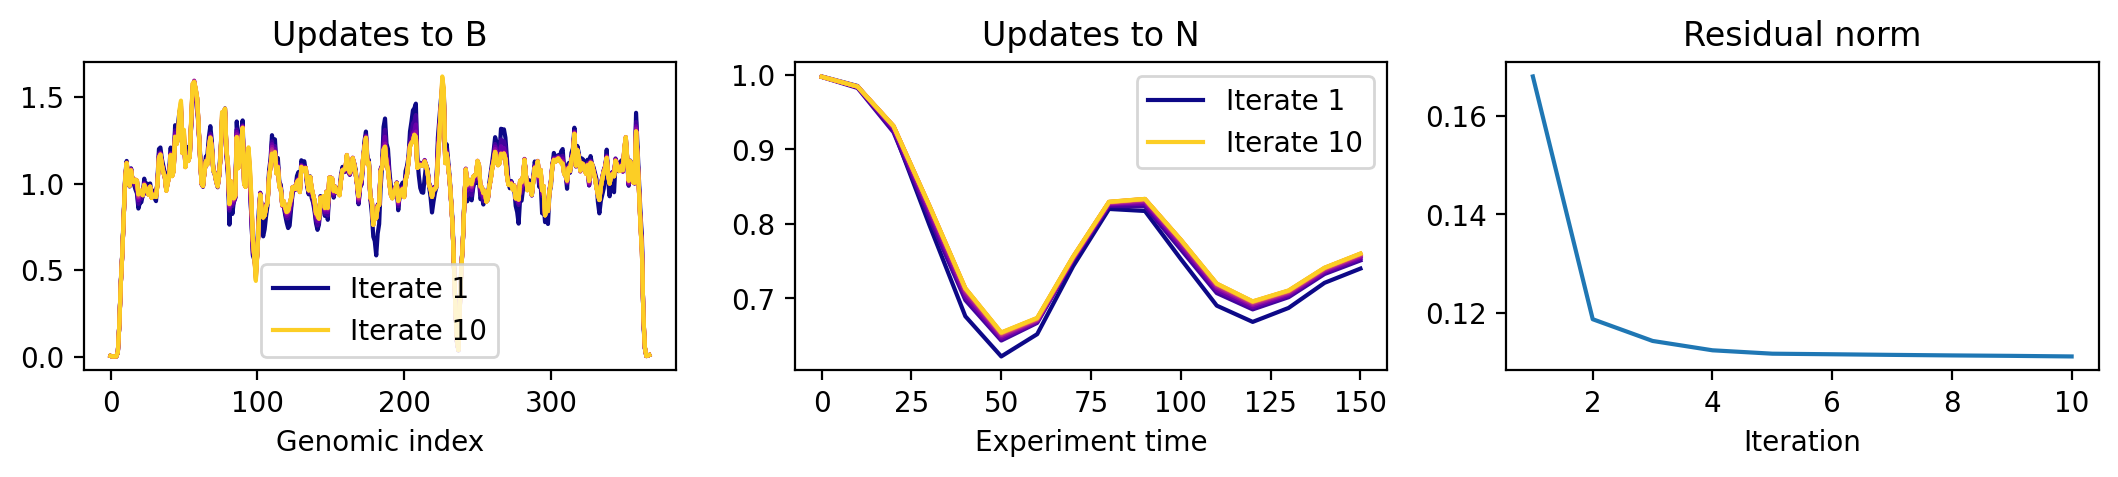

In [394]:

colors = plt.get_cmap('plasma')
num_itr = len(real_deconv1.iterative_update_rns)

plt.figure(figsize=(13, 2))
plt.subplot(1, 3, 1)
for i in range(num_itr):
    label = f"Iterate {i+1}" if (i == num_itr-1 or i == 0) else None
    plt.plot(np.diag(real_deconv1.Bs[i]), c=colors(i/num_itr),
             label=label)
plt.legend()
plt.title("Updates to B")
plt.xlabel("Genomic index")

plt.subplot(1, 3, 2)
tps = real_deconv1.config.WT1_TIMEPOINTS
for i in range(num_itr):
    label = f"Iterate {i+1}" if (i == num_itr-1 or i == 0) else None
    plt.plot(tps, np.diag(real_deconv1.Ns[i]), c=colors(i/num_itr), label=label)
plt.legend()
plt.title("Updates to N")
plt.xlabel("Experiment time")

plt.subplot(1, 3, 3)
plt.plot(np.arange(1, num_itr+1), real_deconv1.iterative_update_rns)
plt.title("Residual norm")
plt.xlabel("Iteration")

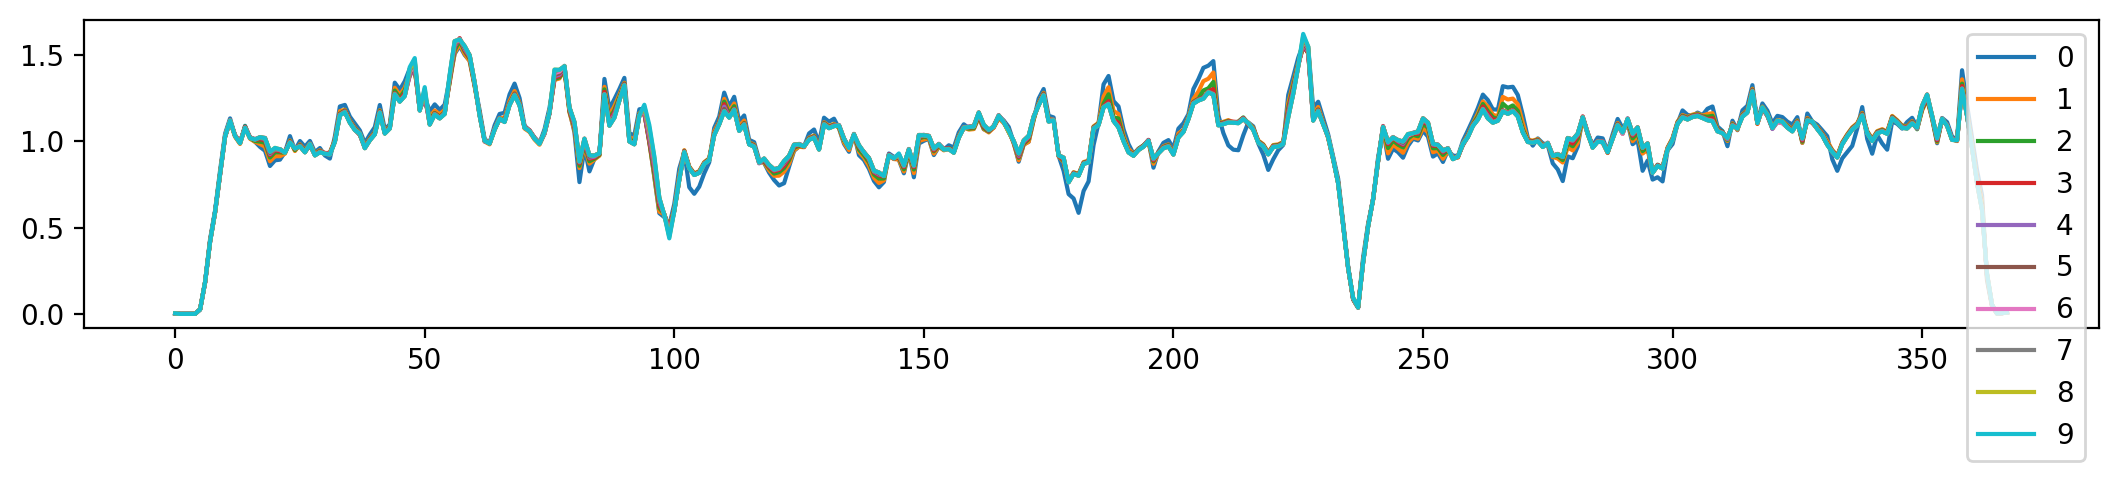

In [351]:
plt.figure(figsize=(13, 2))

for i in range(total_iterations):
    plt.plot(np.diag(real_deconv1.Bs[i]), label=f"{i}")
plt.legend()

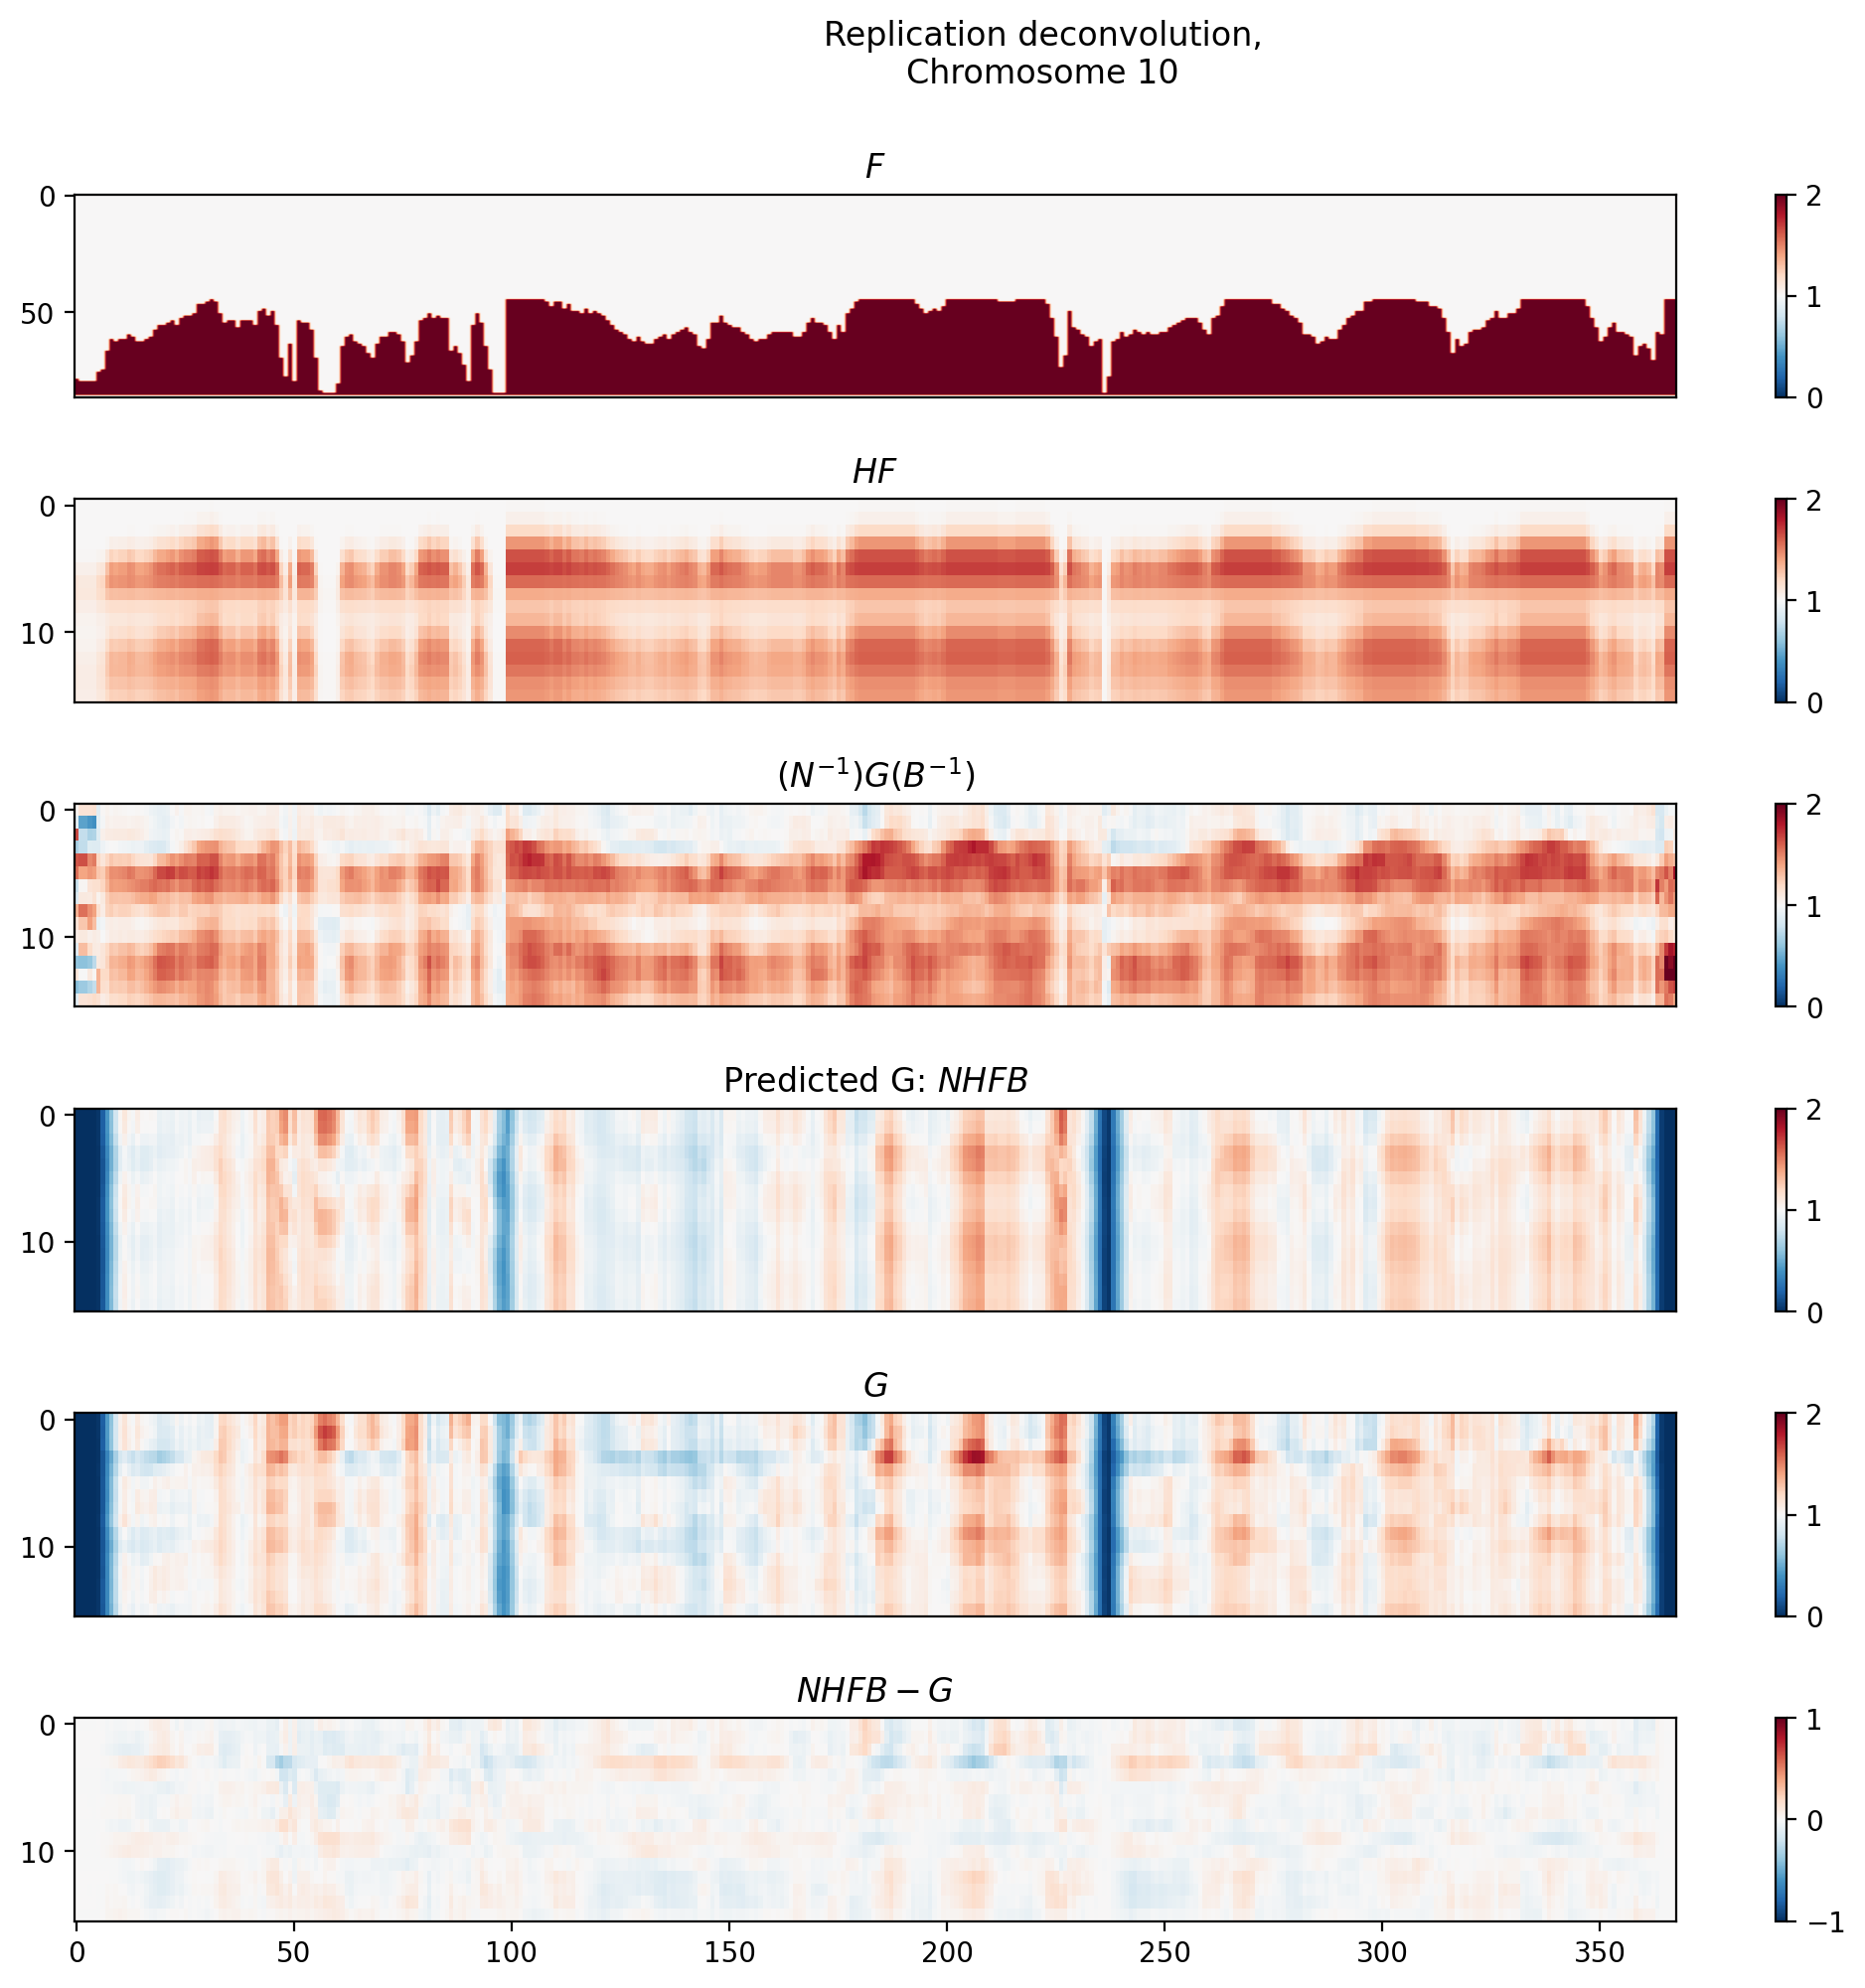

In [341]:
real_deconv1.plot_heatmaps()

In [353]:
deconv_test_g1_replication = RealDataReplicationDeconvolution(config, replicate=1, chr=10)

Initializing N using config H.
Initializing B using timepoint 0


In [361]:
total_iterations = 5
deconv_test_g1_replication.iterative_deconvolution_updates(total_iterations=total_iterations)

Iteration 0
0/368 - 00:00:00.061
50/368 - 00:00:16.543
100/368 - 00:00:34.329
150/368 - 00:00:51.948
200/368 - 00:01:09.485
250/368 - 00:01:27.391
300/368 - 00:01:45.373
350/368 - 00:02:03.148
Iteration completed 00:02:09.052, rn=0.163280887877617
Iteration 1
0/368 - 00:02:09.113
50/368 - 00:02:26.675
100/368 - 00:02:46.342
150/368 - 00:03:04.332
200/368 - 00:03:22.095
250/368 - 00:03:40.400
300/368 - 00:03:58.826
350/368 - 00:04:19.559
Iteration completed 00:04:25.979, rn=0.12216589093676362
Iteration 2
0/368 - 00:04:26.041
50/368 - 00:04:43.444
100/368 - 00:05:01.463
150/368 - 00:05:19.664
200/368 - 00:05:39.189
250/368 - 00:05:57.252
300/368 - 00:06:15.880
350/368 - 00:06:33.918
Iteration completed 00:06:39.800, rn=0.11299736340622482
Iteration 3
0/368 - 00:06:39.860
50/368 - 00:06:56.867
100/368 - 00:07:14.238
150/368 - 00:07:31.715
200/368 - 00:07:49.303
250/368 - 00:08:06.680
300/368 - 00:08:24.306
350/368 - 00:08:41.746
Iteration completed 00:08:47.395, rn=0.11097083302454235
It

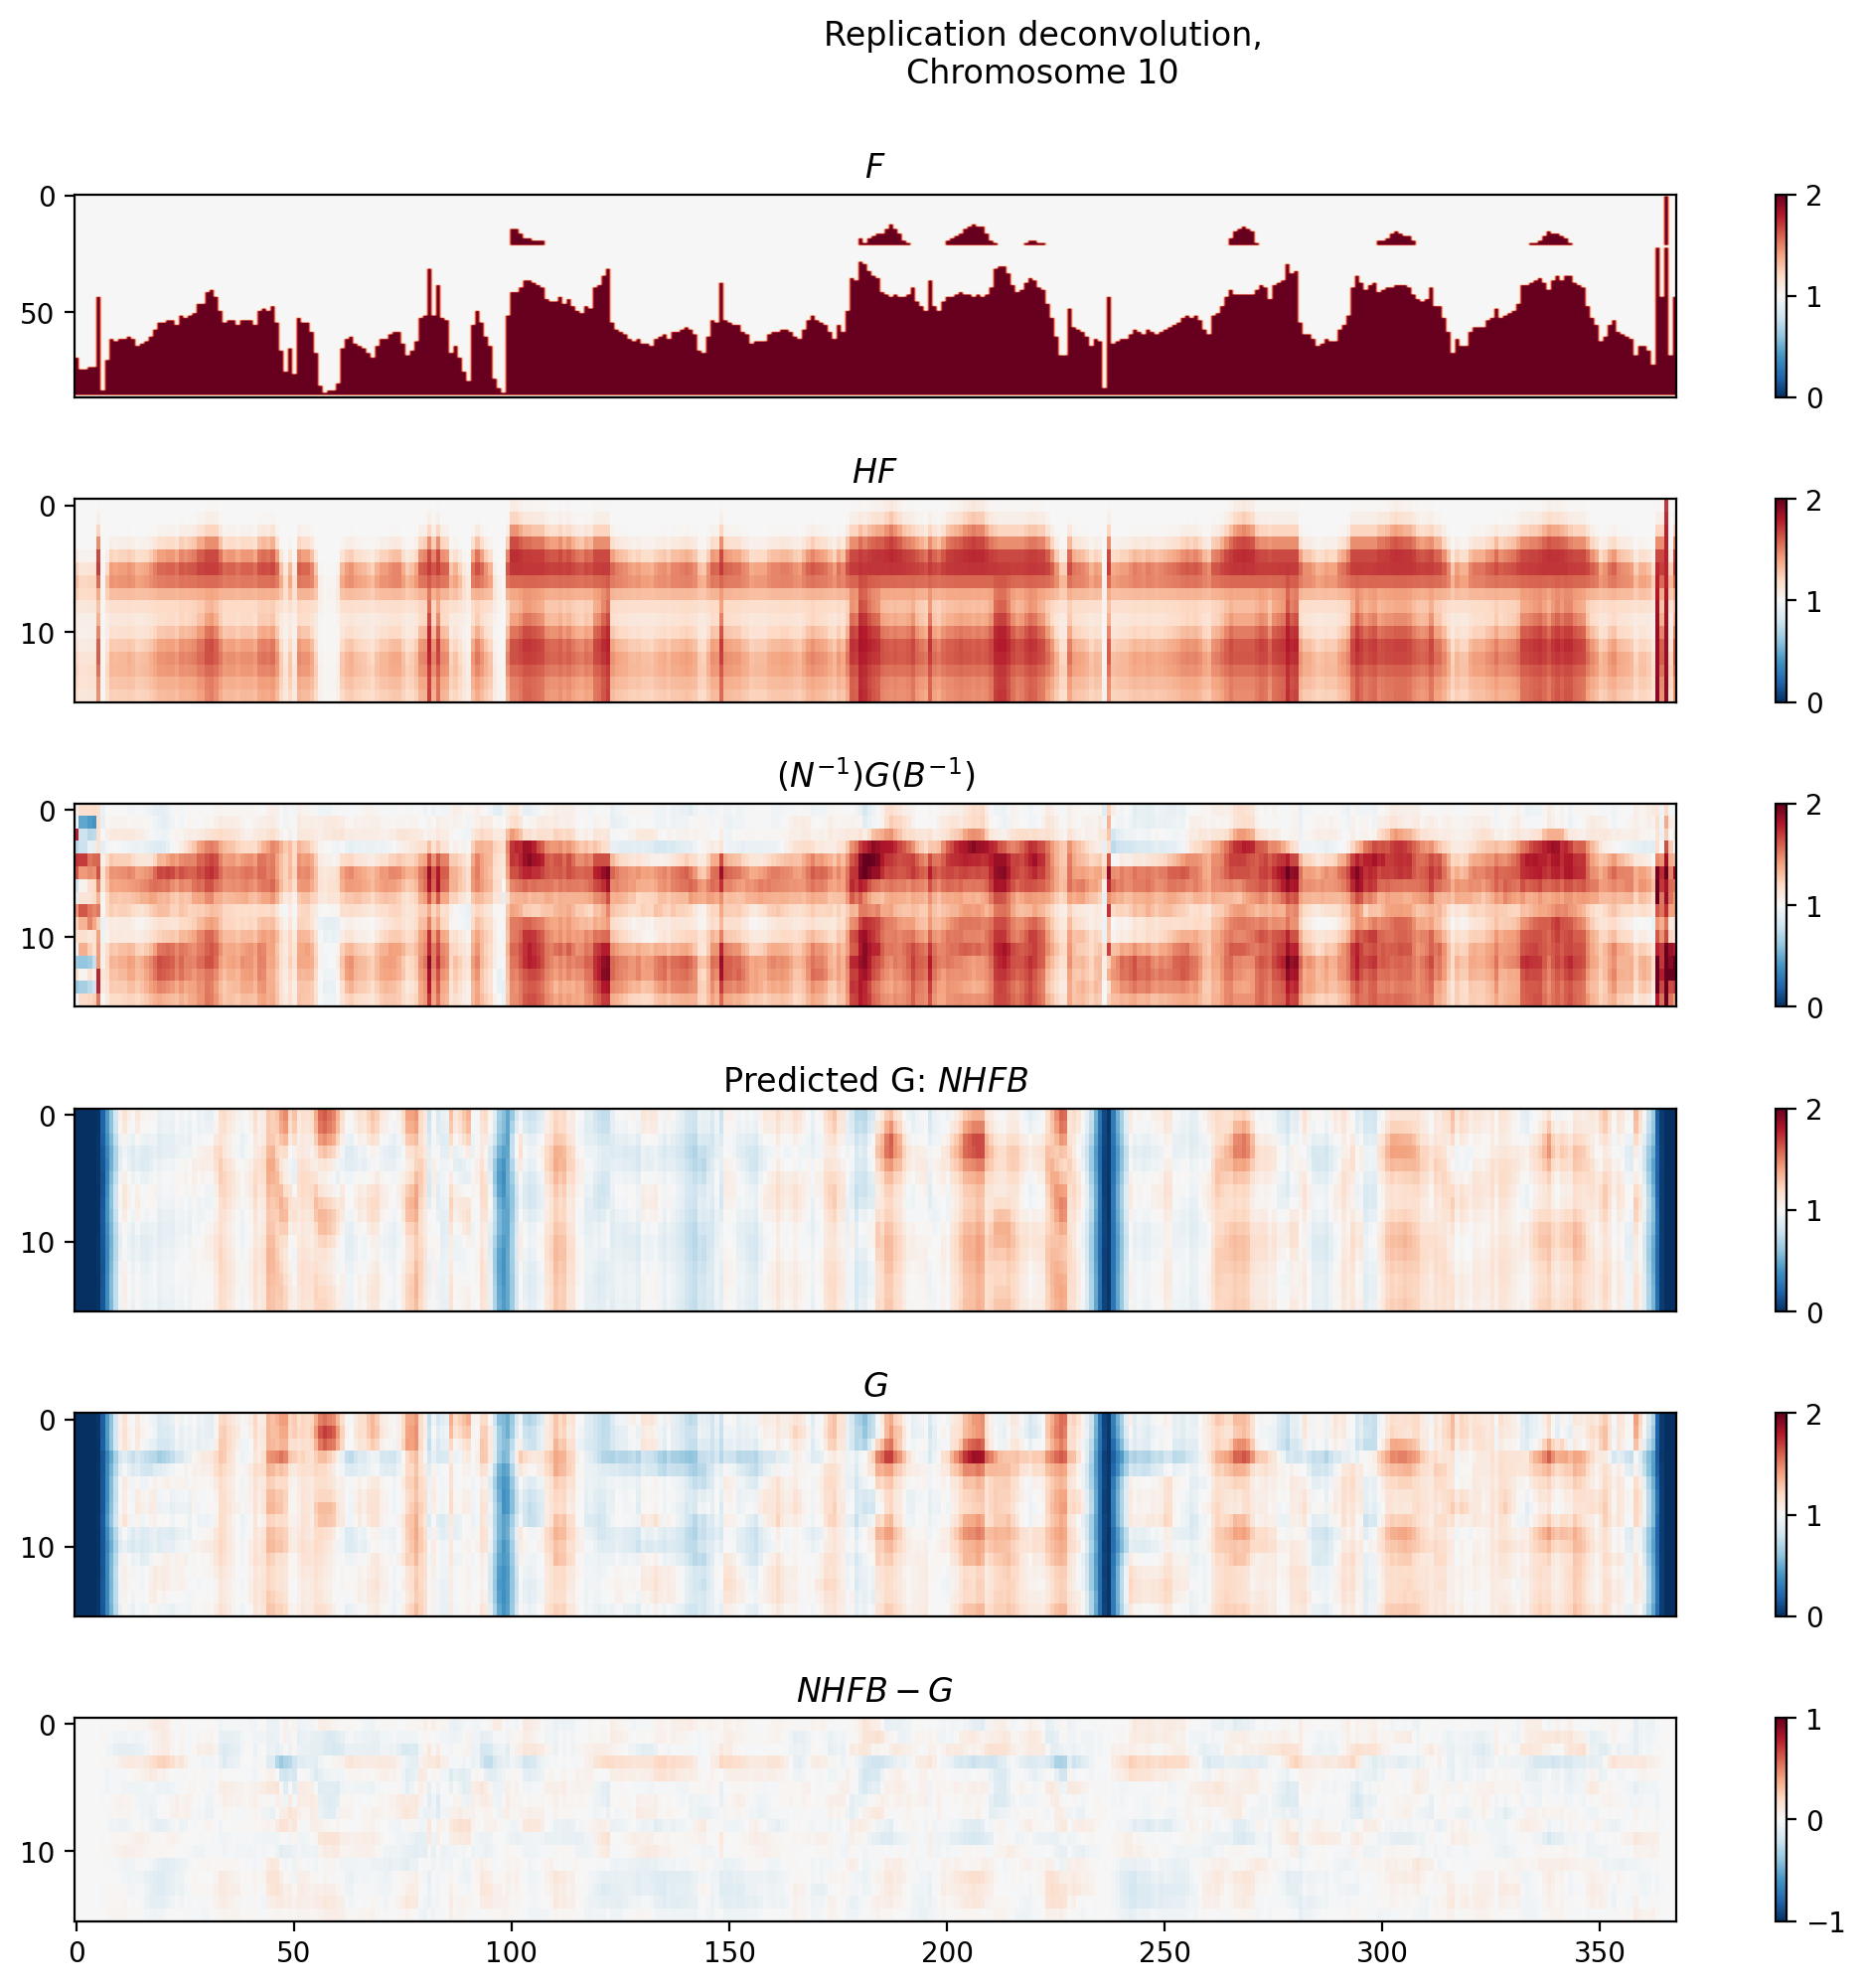

In [362]:
deconv_test_g1_replication.plot_heatmaps()

In [464]:
from src.utils import mkdirs_safe

chroms = [1, 4, 7, 10]
total_iterations = 5

outdir = 'output/replication_deconvolution'
mkdirs_safe([outdir])
timer = Timer()

config1, config2 = load_default_chrom_configs()

for chrom in chroms:
    for replicate in [1, 2]:
        
        config = config1 if replicate == 1 else config2 

        print(f"Creating replication profile for replicate {replicate}, chrom {chrom}")
        deconv_test_g1_replication = RealDataReplicationDeconvolution(config, 
            replicate=replicate, chr=chrom)
        deconv_test_g1_replication.iterative_deconvolution_updates(
            total_iterations=total_iterations, timer=timer)
        deconv_test_g1_replication.plot_heatmaps()
        plt.savefig(f'{outdir}/rep{replicate}_chrom{chrom}_heatmap.png')
        plt.clf()


Creating directory: output/replication_deconvolution...Directory exists. Skipping.
Creating replication profile for replicate 1, chrom 1
Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/111 - 00:00:02.801
50/111 - 00:00:13.044
100/111 - 00:00:22.788
Iteration completed 00:00:24.597, rn=0.1477639292667652
Iteration 1
0/111 - 00:00:24.658
50/111 - 00:00:33.644
100/111 - 00:00:43.308
Iteration completed 00:00:45.052, rn=0.11212143489139474
Iteration 2
0/111 - 00:00:45.113
50/111 - 00:00:53.855
100/111 - 00:01:03.317
Iteration completed 00:01:05.089, rn=0.10794465859714059
Iteration 3
0/111 - 00:01:05.147
50/111 - 00:01:15.061
100/111 - 00:01:23.762
Iteration completed 00:01:25.830, rn=0.10576467484958947
Iteration 4
0/111 - 00:01:25.894
50/111 - 00:01:35.451
100/111 - 00:01:44.248
Iteration completed 00:01:46.623, rn=0.1050049520772084
Creating replication profile for replicate 2, chrom 1
Initializing N using config H.
Initializing B using timepoint 0
Iteratio

250/541 - 00:38:07.455
300/541 - 00:38:17.760
350/541 - 00:38:26.709
400/541 - 00:38:36.003
450/541 - 00:38:45.752
500/541 - 00:38:54.708
Iteration completed 00:39:01.892, rn=0.060548634826605344
Iteration 1
0/541 - 00:39:01.955
50/541 - 00:39:10.850
100/541 - 00:39:20.890
150/541 - 00:39:30.191
200/541 - 00:39:39.246
250/541 - 00:39:49.054
300/541 - 00:39:58.138
350/541 - 00:40:07.138
400/541 - 00:40:17.427
450/541 - 00:40:27.314
500/541 - 00:40:36.325
Iteration completed 00:40:44.177, rn=0.040573801691391395
Iteration 2
0/541 - 00:40:44.238
50/541 - 00:40:52.997
100/541 - 00:41:01.837
150/541 - 00:41:11.184
200/541 - 00:41:20.390
250/541 - 00:41:29.356
300/541 - 00:41:39.600
350/541 - 00:41:48.628
400/541 - 00:41:58.288
450/541 - 00:42:08.211
500/541 - 00:42:17.480
Iteration completed 00:42:24.766, rn=0.03668734715784042
Iteration 3
0/541 - 00:42:24.828
50/541 - 00:42:34.604
100/541 - 00:42:43.693
150/541 - 00:42:52.680
200/541 - 00:43:03.032
250/541 - 00:43:11.910
300/541 - 00:43:21

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

In [465]:

chroms = [13]
timer = Timer()

for chrom in chroms:
    for replicate in [1, 2]:
        
        config = config1 if replicate == 1 else config2 

        print(f"Creating replication profile for replicate {replicate}, chrom {chrom}")
        deconv_test_g1_replication = RealDataReplicationDeconvolution(config, 
            replicate=replicate, chr=chrom)
        deconv_test_g1_replication.iterative_deconvolution_updates(
            total_iterations=total_iterations, timer=timer)
        deconv_test_g1_replication.plot_heatmaps()
        plt.savefig(f'{outdir}/rep{replicate}_chrom{chrom}_heatmap.png')
        plt.clf()


Creating replication profile for replicate 1, chrom 13
Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/458 - 00:00:11.994
50/458 - 00:00:20.529
100/458 - 00:00:29.379
150/458 - 00:00:39.072
200/458 - 00:00:47.742
250/458 - 00:00:56.570
300/458 - 00:01:05.226
350/458 - 00:01:14.699
400/458 - 00:01:23.215
450/458 - 00:01:31.590
Iteration completed 00:01:32.996, rn=0.07591175008634178
Iteration 1
0/458 - 00:01:33.056
50/458 - 00:01:42.234
100/458 - 00:01:51.044
150/458 - 00:01:59.495
200/458 - 00:02:08.754
250/458 - 00:02:18.739
300/458 - 00:02:27.903
350/458 - 00:02:37.195
400/458 - 00:02:47.116
450/458 - 00:02:55.917
Iteration completed 00:02:57.357, rn=0.05773392827852283
Iteration 2
0/458 - 00:02:57.415
50/458 - 00:03:05.942
100/458 - 00:03:15.075
150/458 - 00:03:24.576
200/458 - 00:03:33.367
250/458 - 00:03:42.187
300/458 - 00:03:51.722
350/458 - 00:04:00.424
400/458 - 00:04:09.012
450/458 - 00:04:17.586
Iteration completed 00:04:19.009, rn=0.05477539889

<Figure size 1300x1100 with 0 Axes>

<Figure size 1300x1100 with 0 Axes>

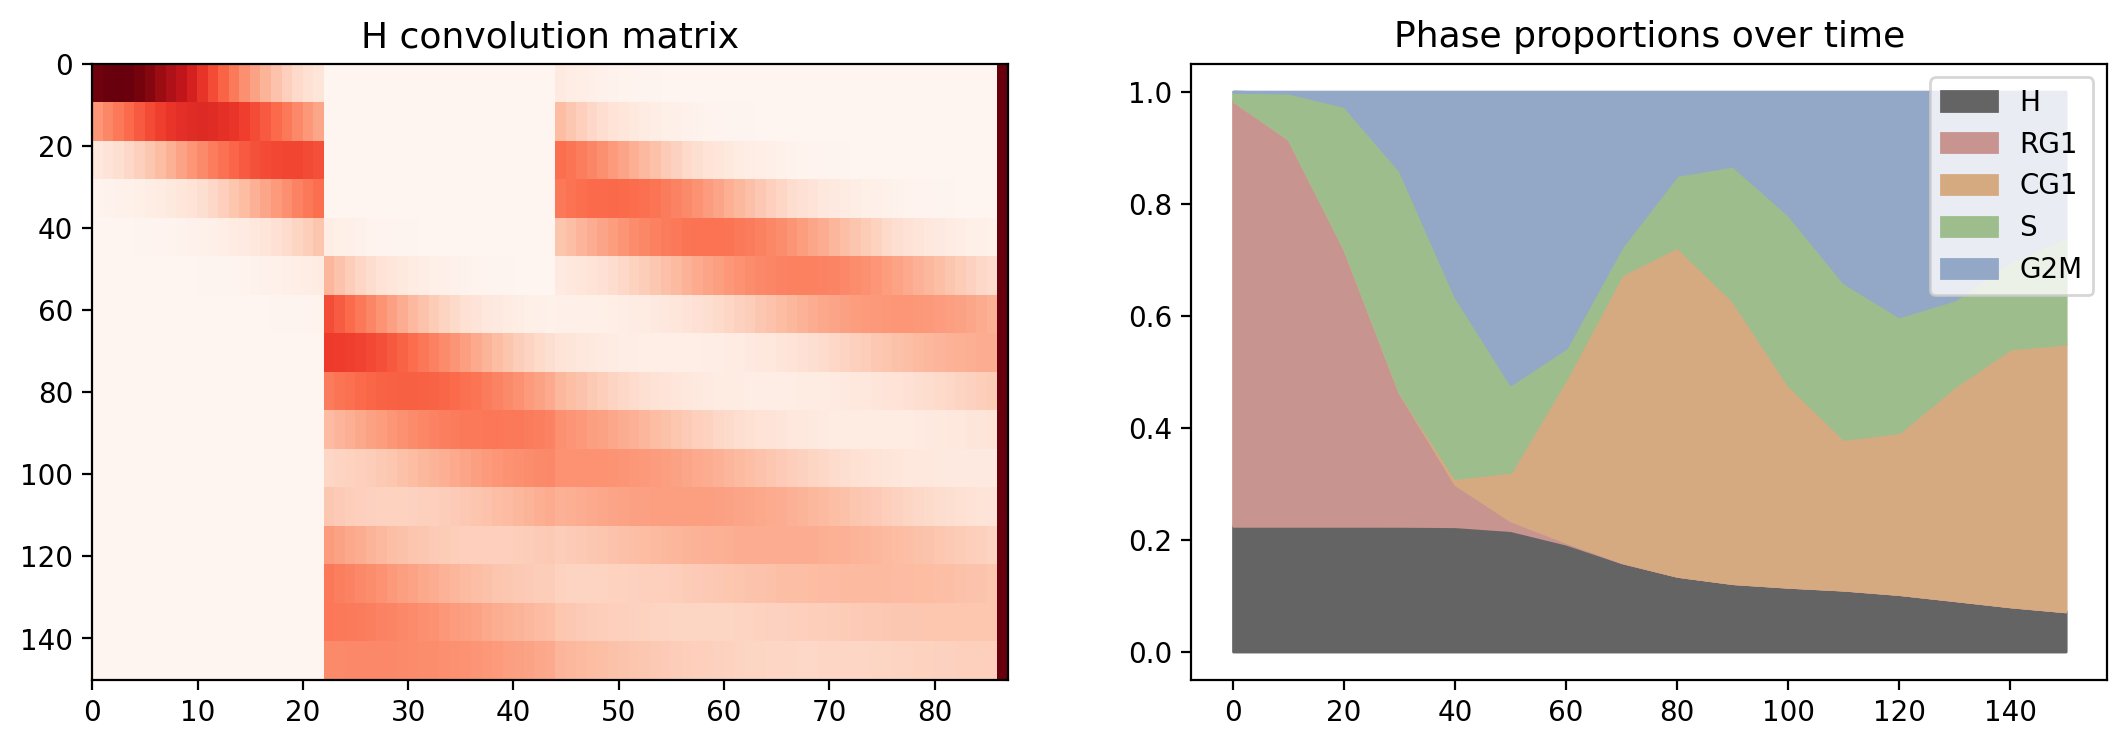

In [526]:
from src.config import plot_H

config, _ = load_default_chrom_configs()
config.calculate_H()

plot_H(config, config.H)


In [527]:
config.parameters

,value
mu0,23.8956
lambda,71.5240
delta,2.8000
sigma0,10.7800
sigmav,0.1442
alpha,22.0000
beta,0.0000
gamma1,0.0470
gamma2,0.2785
halted,0.2245


In [528]:
deconv_test_g1_replication = RealDataReplicationDeconvolution(config, 
    replicate=1, chr=10)
deconv_test_g1_replication.iterative_deconvolution_updates(
    total_iterations=2)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/368 - 00:00:00.063
50/368 - 00:00:14.383
100/368 - 00:00:26.436
150/368 - 00:00:37.137
200/368 - 00:00:47.031
250/368 - 00:00:57.731
300/368 - 00:01:08.113
350/368 - 00:01:17.668
Iteration completed 00:01:21.820, rn=0.1693836270176987
Iteration 1
0/368 - 00:01:21.885
50/368 - 00:01:31.373
100/368 - 00:01:41.723
150/368 - 00:01:51.801
200/368 - 00:02:01.417
250/368 - 00:02:12.914
300/368 - 00:02:23.316
350/368 - 00:02:33.933
Iteration completed 00:02:37.264, rn=0.11985729597843395


In [533]:
F, H, B, G, N = deconv_test_g1_replication.F, deconv_test_g1_replication.H, \
    deconv_test_g1_replication.B, deconv_test_g1_replication.G, deconv_test_g1_replication.N


(16, 368)

Text(0.5, 1.0, 'Average replication profile')

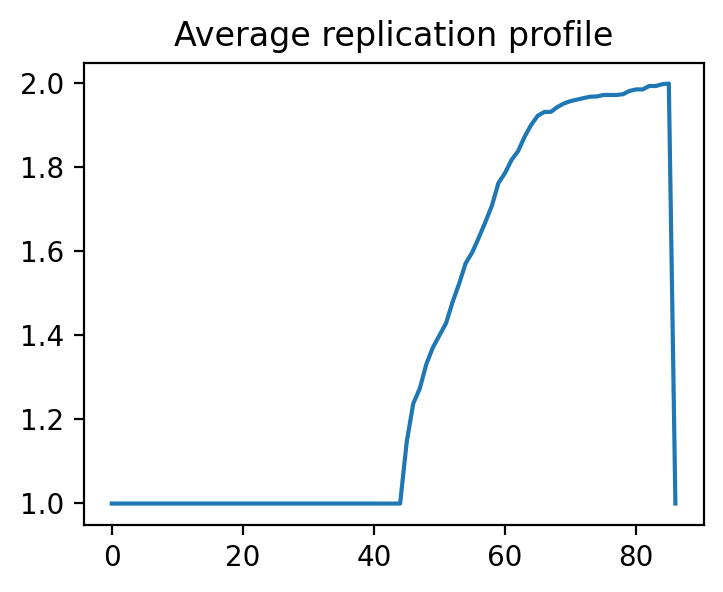

In [543]:
plt.figure(figsize=(4, 3))
plt.plot((F@B).mean(axis=1))
plt.title("Average replication profile")

Text(0.5, 1.0, 'Average DNA content, row means of HFB')

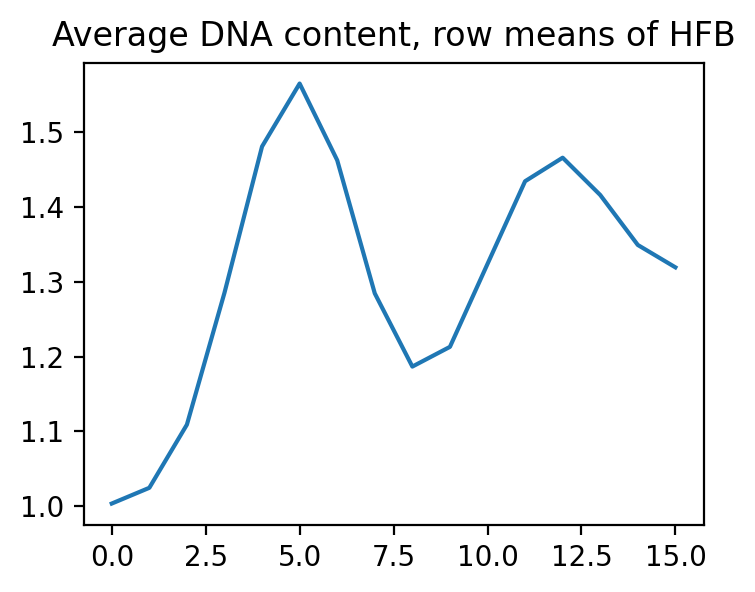

In [541]:
plt.figure(figsize=(4, 3))
plt.plot((H@F@B).mean(axis=1), label="HFB")
plt.title("Average DNA content, row means of HFB")

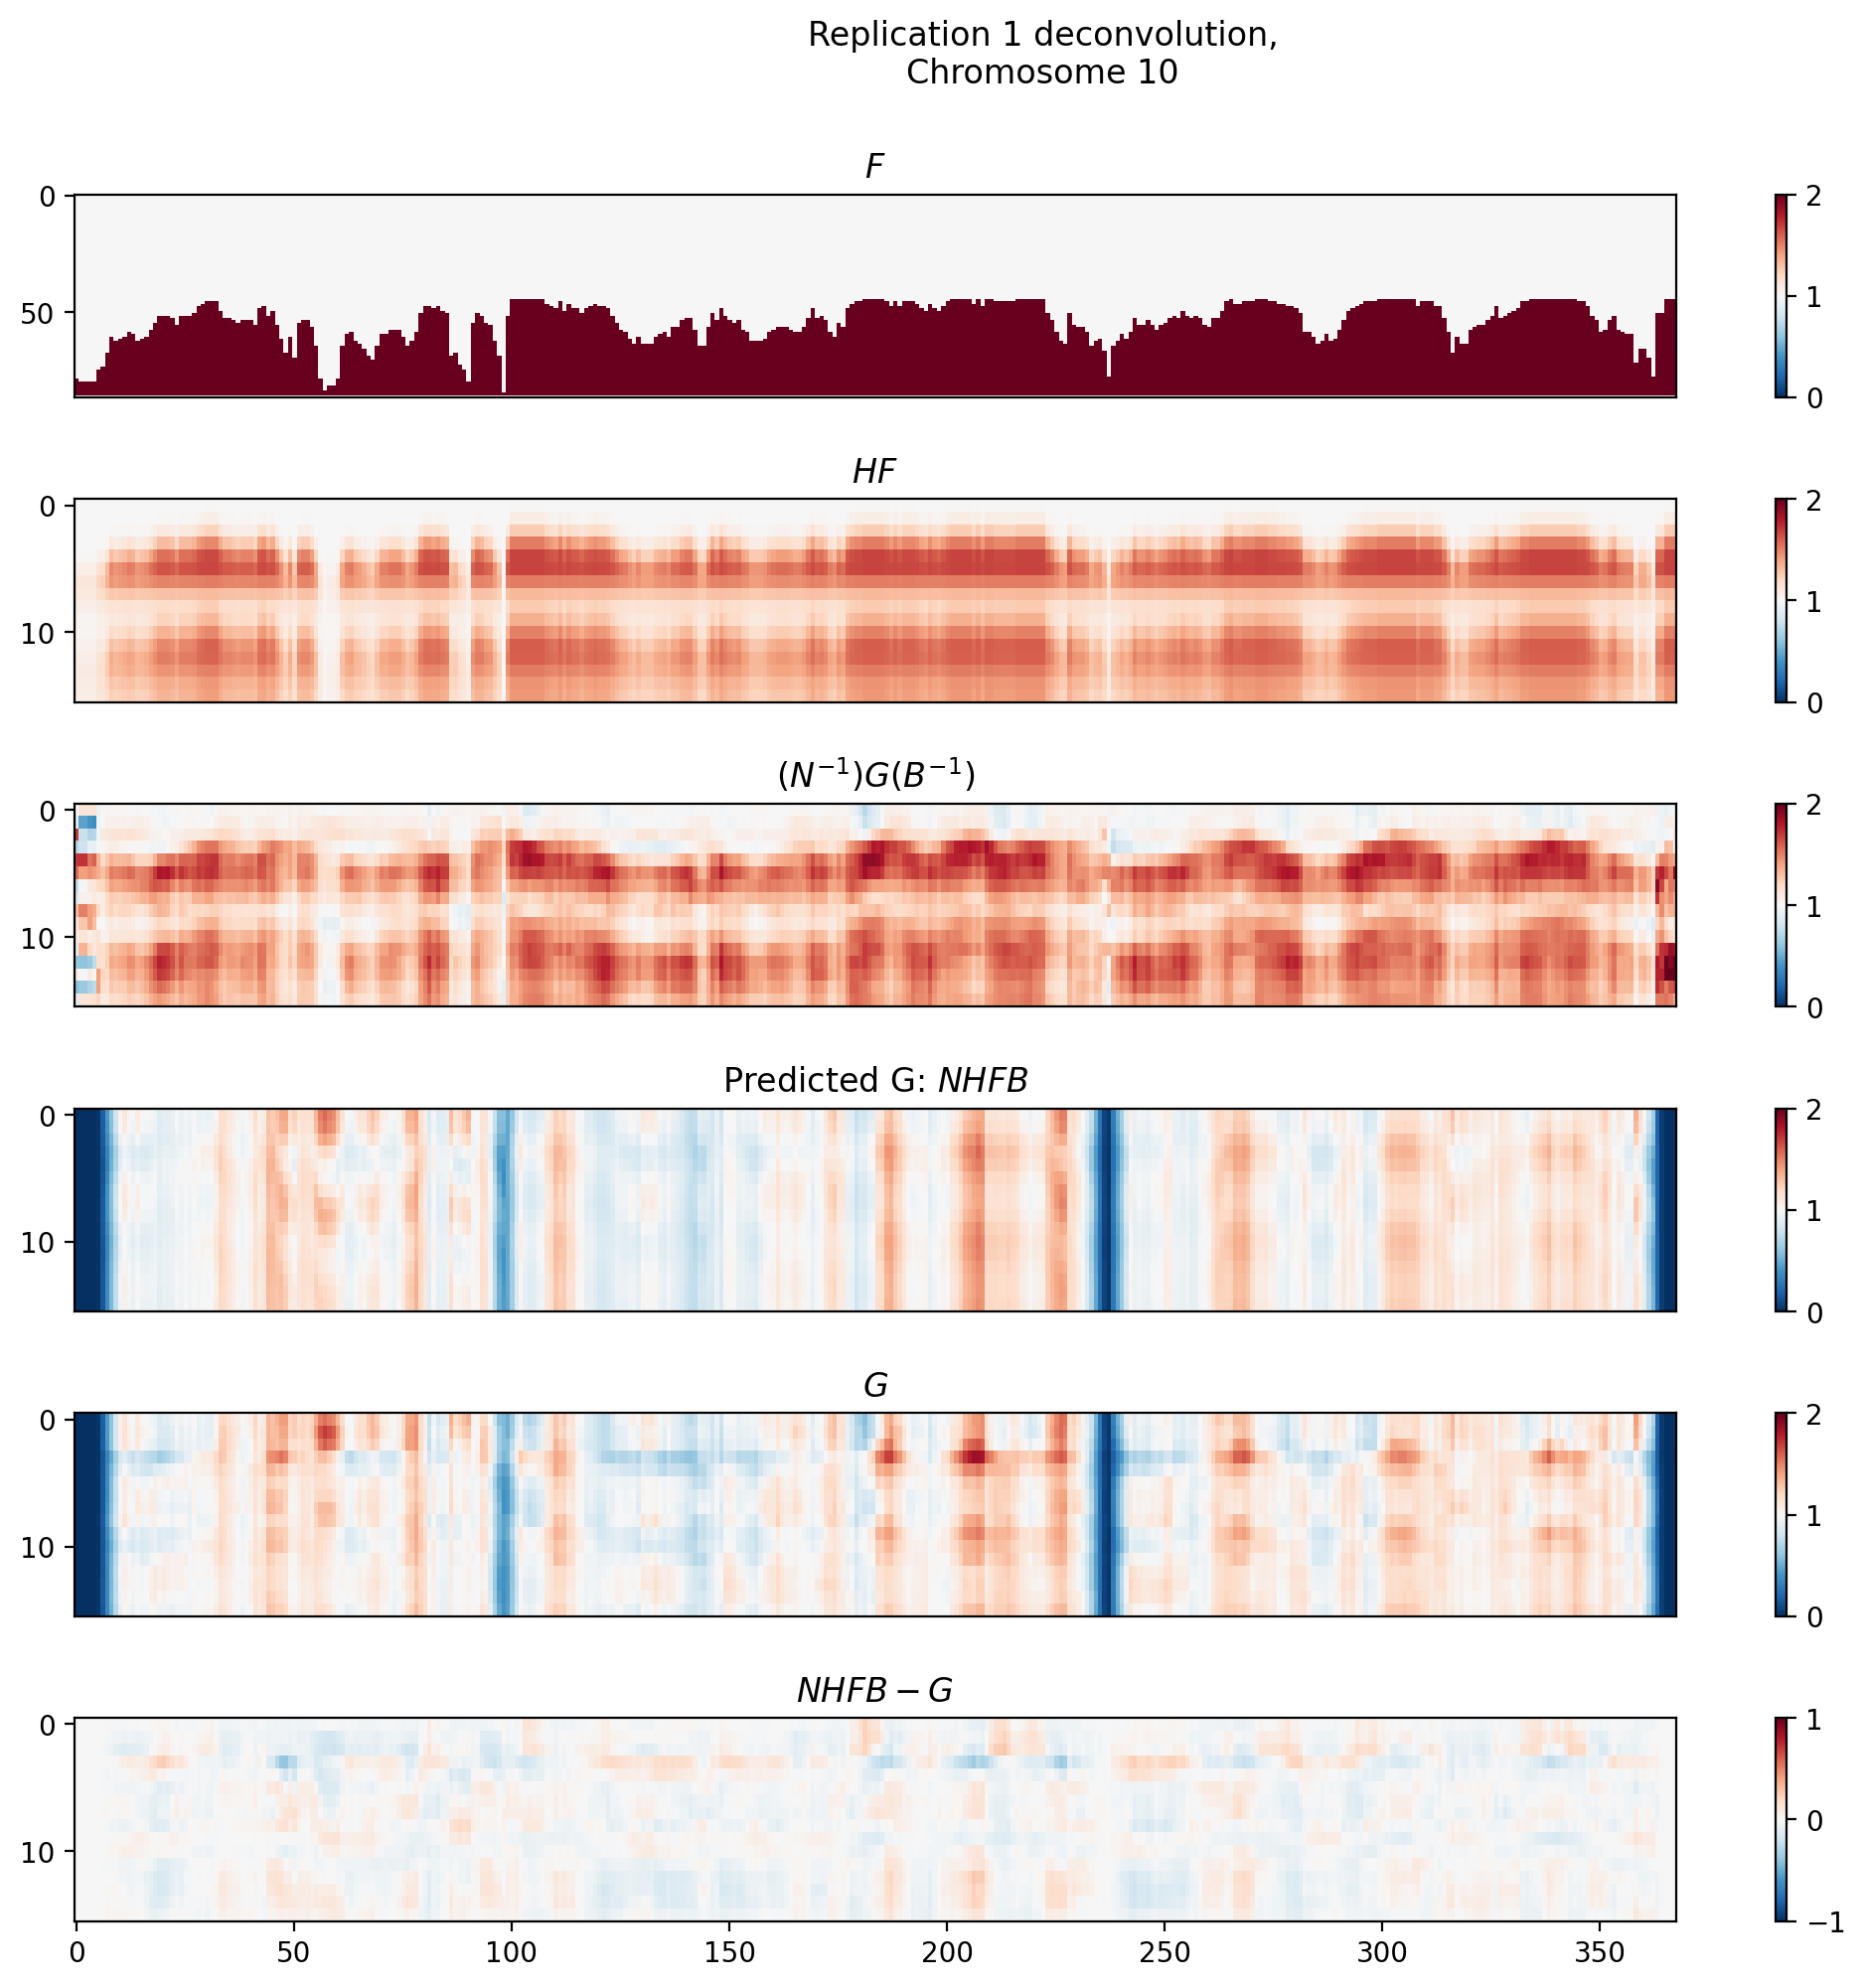

In [529]:
deconv_test_g1_replication.plot_heatmaps()
plt.savefig('output/replication_deconvolution/rep1_chrom10_heatmap_testing_mu0_22_sigma0_4_sigmav_0.1.png')

In [604]:
from scipy.stats.distributions import norm

noise = norm.rvs(loc=0, scale=0.001, size=F.shape)

F_noise = F+noise
F_noise_inv = np.linalg.pinv(F_noise)

In [814]:
model_intervals = config.intervals_wt1
timepoints = config.WT1_TIMEPOINTS

In [884]:
F, H, B, G, N = real_deconv1.F, real_deconv1.H, \
    real_deconv1.B, real_deconv1.G, real_deconv1.N

In [885]:
from src.optimize_H import ParameterOptimizer

In [889]:

# Example usage:
initial_values = {
	'mu0': 26.7901,
	'lambda_val': 68.1914,
	'delta': 8.1805,
	'sigma0': 10.9885,
	'sigmav': 0.1424,
	'alpha': 22.0,
	'beta': 0.0,
	'halted': 0.2245
}

initial_values

{'mu0': 26.7901,
 'lambda_val': 68.1914,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'alpha': 22.0,
 'beta': 0.0,
 'halted': 0.2245}

In [896]:
initial_values

{'mu0': 26.7901,
 'lambda_val': 68.1914,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'alpha': 22.0,
 'beta': 0.0,
 'halted': 0.2245}

In [906]:
optimal_params

{'mu0': 20.893334023037536,
 'lambda_val': 65.3909644943705,
 'delta': 2.576401175967331e-08,
 'sigma0': 4.841485254262888,
 'sigmav': 0.1337437882845042,
 'alpha': 17.600000018720735,
 'beta': 0.0,
 'halted': 0.20000054637316764}

In [908]:
timer = Timer()

num_epochs = 25
params_df = pd.DataFrame()

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    optimizer = ParameterOptimizer(
        initial_values=initial_values,
        model_intervals=model_intervals,
        timepoints=timepoints,
        N=N,
        F=F,
        B=B,
        G=G
    )
    optimal_params, loss = optimizer.optimize(maxiter=10000, verbose=False)

    # Construct updated H
    intervals = list(model_intervals)
    intervals[0] = [v for k, v in optimal_params.items()]
    H, _ = calcH(intervals, timepoints)

    deconv_test_g1_replication.H = H
    deconv_test_g1_replication.iterative_deconvolution_updates(
        total_iterations=4, timer=timer)
    timer.print_time()
    
    params_row = pd.DataFrame([optimal_params], index=[epoch])
    params_row['opt_H_loss'] = loss
    params_row['F_rn'] = deconv_test_g1_replication.rn

    params_df = pd.concat([params_df, params_row])
    
    N = deconv_test_g1_replication.N
    B = deconv_test_g1_replication.B
    F = deconv_test_g1_replication.F
    

Epoch:  0
Bounds:  [(18, 28), (55, 75), (0, 16), (1, 12), (0.04, 0.25), (0, 26), (0, 0), (0.1, 0.25)]
Iteration 0
0/368 - 00:08:20.520
50/368 - 00:08:29.699
100/368 - 00:08:39.531
150/368 - 00:08:48.618
200/368 - 00:08:57.916
250/368 - 00:09:07.309
300/368 - 00:09:21.109
350/368 - 00:09:30.887
Iteration completed 00:09:34.160, rn=0.21725618263241864
Iteration 1
0/368 - 00:09:34.227
50/368 - 00:09:43.841
100/368 - 00:09:53.839
150/368 - 00:10:03.919
200/368 - 00:10:13.538
250/368 - 00:10:23.506
300/368 - 00:10:32.549
350/368 - 00:10:41.388
Iteration completed 00:10:44.463, rn=0.11411336742534535
Iteration 2
0/368 - 00:10:44.524
50/368 - 00:10:53.247
100/368 - 00:11:03.702
150/368 - 00:11:12.861
200/368 - 00:11:21.586
250/368 - 00:11:30.830
300/368 - 00:11:39.668
350/368 - 00:11:48.492
Iteration completed 00:11:51.846, rn=0.10662518855538468
Iteration 3
0/368 - 00:11:51.910
50/368 - 00:12:03.780
100/368 - 00:12:14.620
150/368 - 00:12:34.512
200/368 - 00:12:43.390
250/368 - 00:12:52.347
3

100/368 - 01:33:52.388
150/368 - 01:34:06.438
200/368 - 01:34:15.181
250/368 - 01:34:23.876
300/368 - 01:34:32.399
350/368 - 01:34:40.983
Iteration completed 01:34:44.066, rn=0.11434114152514384
Iteration 2
0/368 - 01:34:44.125
50/368 - 01:34:52.740
100/368 - 01:35:01.790
150/368 - 01:35:10.590
200/368 - 01:35:19.388
250/368 - 01:35:28.484
300/368 - 01:35:37.291
350/368 - 01:35:46.294
Iteration completed 01:35:49.462, rn=0.10681156878511563
Iteration 3
0/368 - 01:35:49.524
50/368 - 01:35:58.523
100/368 - 01:36:08.203
150/368 - 01:36:16.934
200/368 - 01:36:25.850
250/368 - 01:36:34.703
300/368 - 01:36:43.418
350/368 - 01:36:52.461
Iteration completed 01:36:55.661, rn=0.10483767355532968
01:36:55.662
Epoch:  8
Bounds:  [(18, 28), (55, 75), (0, 16), (1, 12), (0.04, 0.25), (0, 26), (0, 0), (0.1, 0.25)]
Iteration 0
0/368 - 01:45:47.293
50/368 - 01:46:01.527
100/368 - 01:46:10.857
150/368 - 01:46:20.168
200/368 - 01:46:30.049
250/368 - 01:46:39.310
300/368 - 01:46:48.211
350/368 - 01:46:57.0

50/368 - 03:19:37.896
100/368 - 03:19:47.362
150/368 - 03:19:56.063
200/368 - 03:20:04.987
250/368 - 03:20:19.244
300/368 - 03:20:28.160
350/368 - 03:20:37.145
Iteration completed 03:20:40.372, rn=0.10508938588973833
03:20:40.372
Epoch:  15
Bounds:  [(18, 28), (55, 75), (0, 16), (1, 12), (0.04, 0.25), (0, 26), (0, 0), (0.1, 0.25)]
Iteration 0
0/368 - 03:39:00.597
50/368 - 03:39:09.882
100/368 - 03:39:19.324
150/368 - 03:39:28.758
200/368 - 03:39:38.066
250/368 - 03:39:47.200
300/368 - 03:39:56.452
350/368 - 03:40:05.747
Iteration completed 03:40:09.009, rn=0.21514171343253521
Iteration 1
0/368 - 03:40:09.070
50/368 - 03:40:18.090
100/368 - 03:40:27.492
150/368 - 03:40:35.952
200/368 - 03:40:44.564
250/368 - 03:40:53.161
300/368 - 03:41:01.651
350/368 - 03:41:10.253
Iteration completed 03:41:13.367, rn=0.11452978890691431
Iteration 2
0/368 - 03:41:13.425
50/368 - 03:41:22.199
100/368 - 03:41:31.849
150/368 - 03:41:45.856
200/368 - 03:41:54.741
250/368 - 03:42:03.626
300/368 - 03:42:12.3

100/368 - 05:06:54.251
150/368 - 05:07:03.439
200/368 - 05:07:18.216
250/368 - 05:07:27.671
300/368 - 05:07:37.284
350/368 - 05:07:46.476
Iteration completed 05:07:49.749, rn=0.21403213510058272
Iteration 1
0/368 - 05:07:49.810
50/368 - 05:07:58.867
100/368 - 05:08:08.530
150/368 - 05:08:17.452
200/368 - 05:08:26.599
250/368 - 05:08:36.369
300/368 - 05:08:45.796
350/368 - 05:08:55.876
Iteration completed 05:09:00.784, rn=0.11513622532803848
Iteration 2
0/368 - 05:09:00.908
50/368 - 05:09:10.849
100/368 - 05:09:20.672
150/368 - 05:09:29.369
200/368 - 05:09:38.527
250/368 - 05:09:47.021
300/368 - 05:09:55.328
350/368 - 05:10:03.801
Iteration completed 05:10:06.844, rn=0.10697196337791758
Iteration 3
0/368 - 05:10:06.902
50/368 - 05:10:15.474
100/368 - 05:10:24.378
150/368 - 05:10:33.057
200/368 - 05:10:47.072
250/368 - 05:10:55.513
300/368 - 05:11:03.759
350/368 - 05:11:12.267
Iteration completed 05:11:15.284, rn=0.10479752728328526
05:11:15.285
Epoch:  23
Bounds:  [(18, 28), (55, 75), (

In [909]:
# real_deconv1.plot_heatmaps()

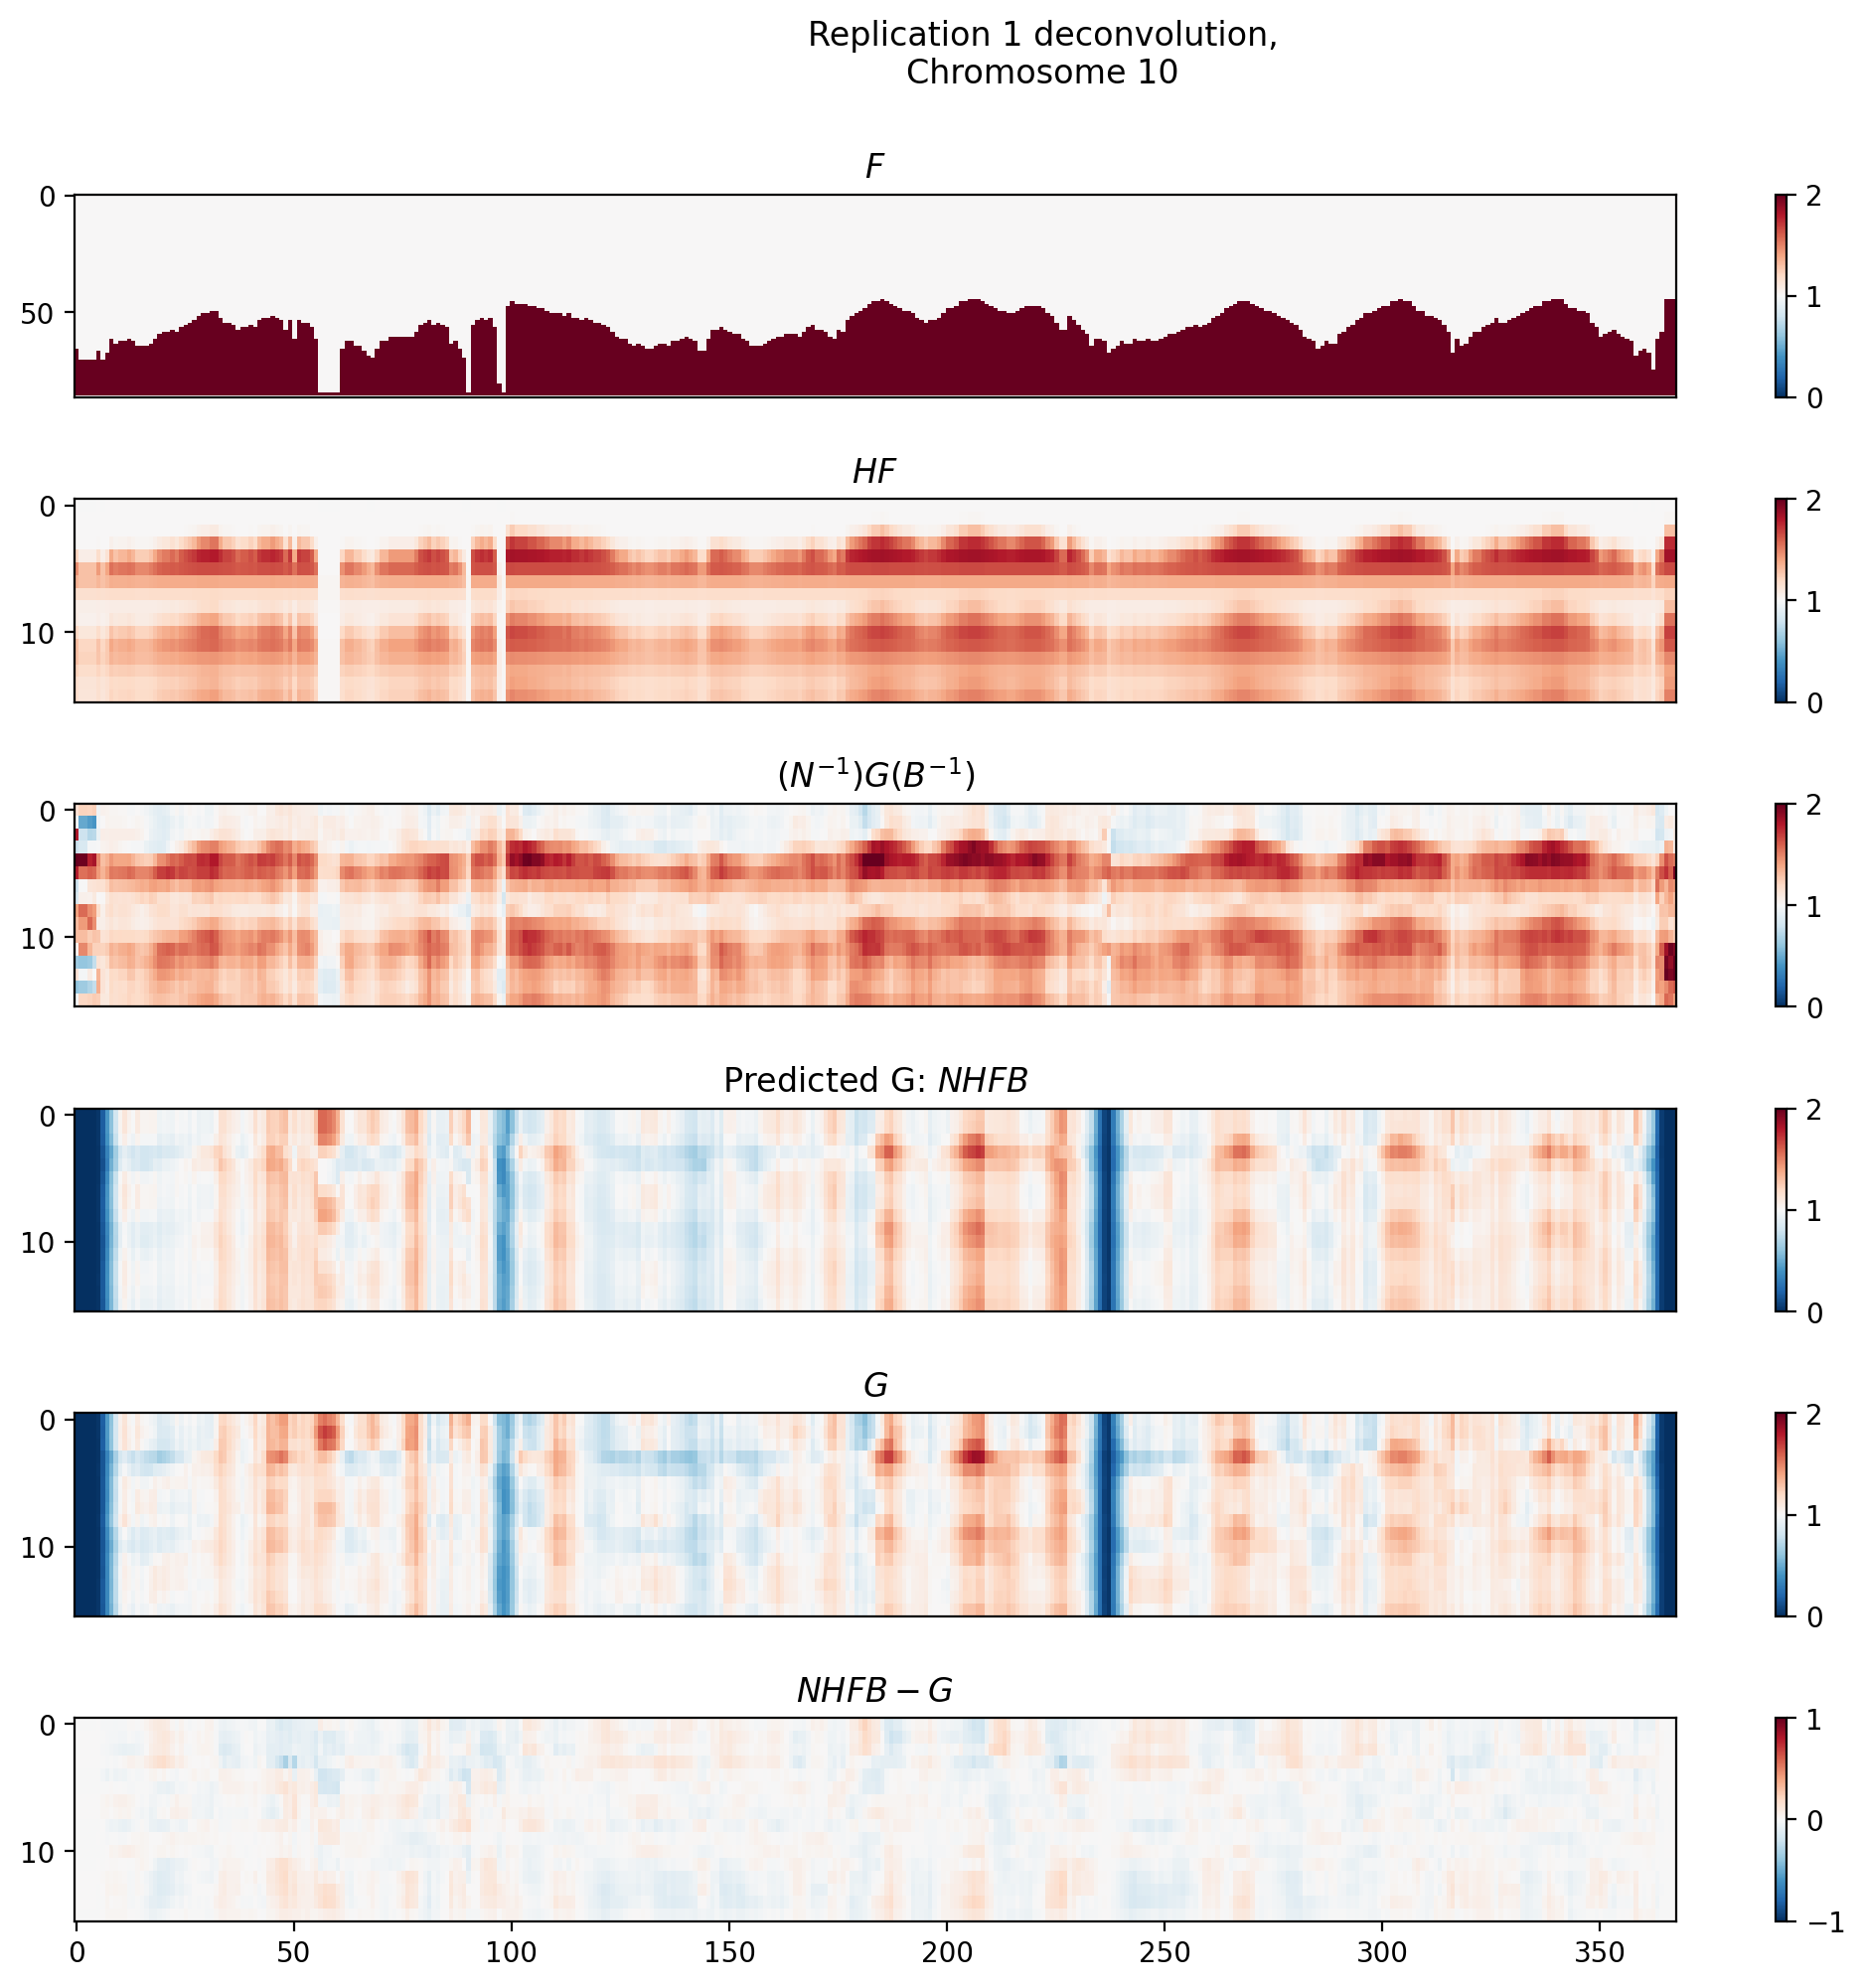

In [910]:
deconv_test_g1_replication.plot_heatmaps()

Text(0.5, 0.98, 'Cell cycle parameter updates, 100 updates')

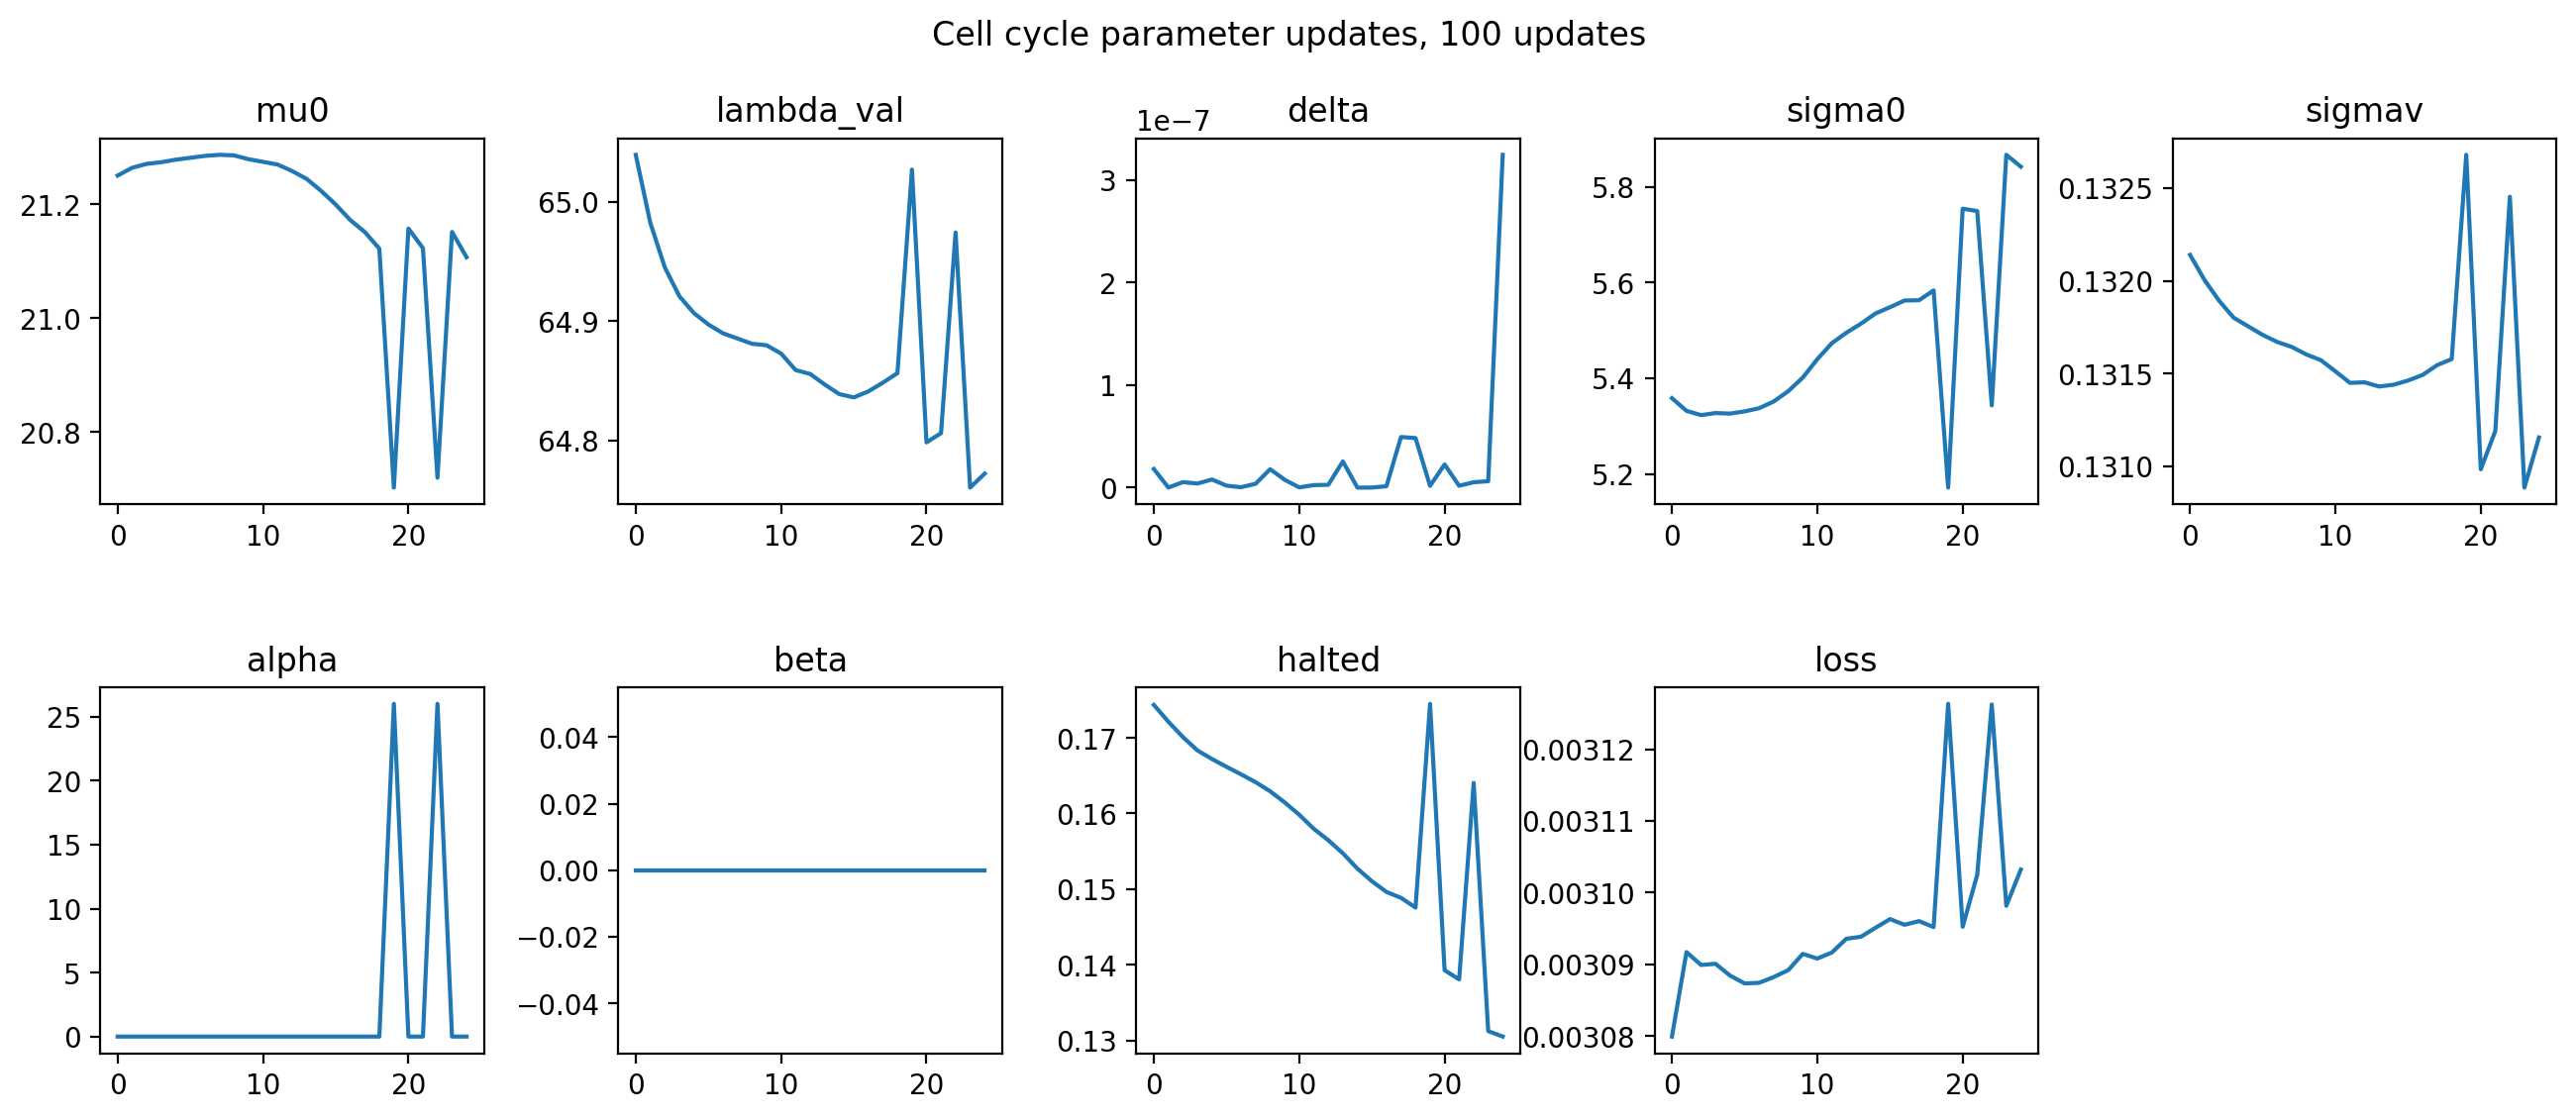

In [914]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle("Cell cycle parameter updates, 100 updates")

In [915]:
params_df

,mu0,lambda_val,delta,sigma0,sigmav,alpha,beta,halted,loss
0,21.250736,65.039146,1.806521e-08,5.358286,0.132140,2.968427e-06,0.0,0.174357,0.003080
1,21.264452,64.982200,0.000000e+00,5.331833,0.132004,1.706351e-08,0.0,0.172127,0.003092
2,21.271271,64.944856,5.320249e-09,5.322855,0.131892,4.072989e-07,0.0,0.170104,0.003090
3,21.274157,64.920675,3.934517e-09,5.327219,0.131801,0.000000e+00,0.0,0.168334,0.003090
4,21.278582,64.906572,7.886408e-09,5.326072,0.131754,8.661191e-07,0.0,0.167200,0.003088
5,21.281897,64.896995,1.846048e-09,5.330650,0.131708,1.464727e-09,0.0,0.166169,0.003087
6,21.285251,64.889619,3.564588e-10,5.337366,0.131670,3.387999e-08,0.0,0.165176,0.003087
7,21.287103,64.885275,3.712240e-09,5.351399,0.131643,1.729367e-07,0.0,0.164138,0.003088
8,21.286182,64.880865,1.793903e-08,5.372930,0.131603,0.000000e+00,0.0,0.162938,0.003089
9,21.279457,64.879603,7.604036e-09,5.401406,0.131572,2.191980e-08,0.0,0.161462,0.003091


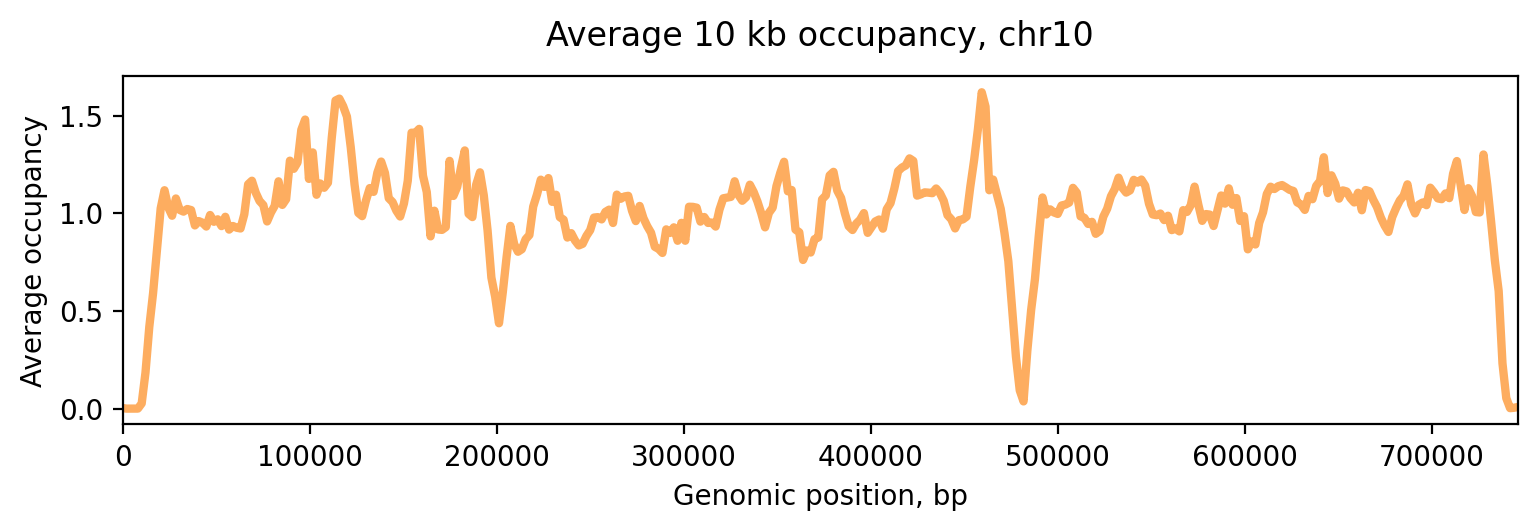

In [942]:
real_deconv1.plot_B()
save_figure_for_paper(
    'output/figures/Replication_Deconvolution/Average_occupancy_chr10_rep1.png')


In [1093]:
deconv_test_g1_replication.compute_replication_profile()

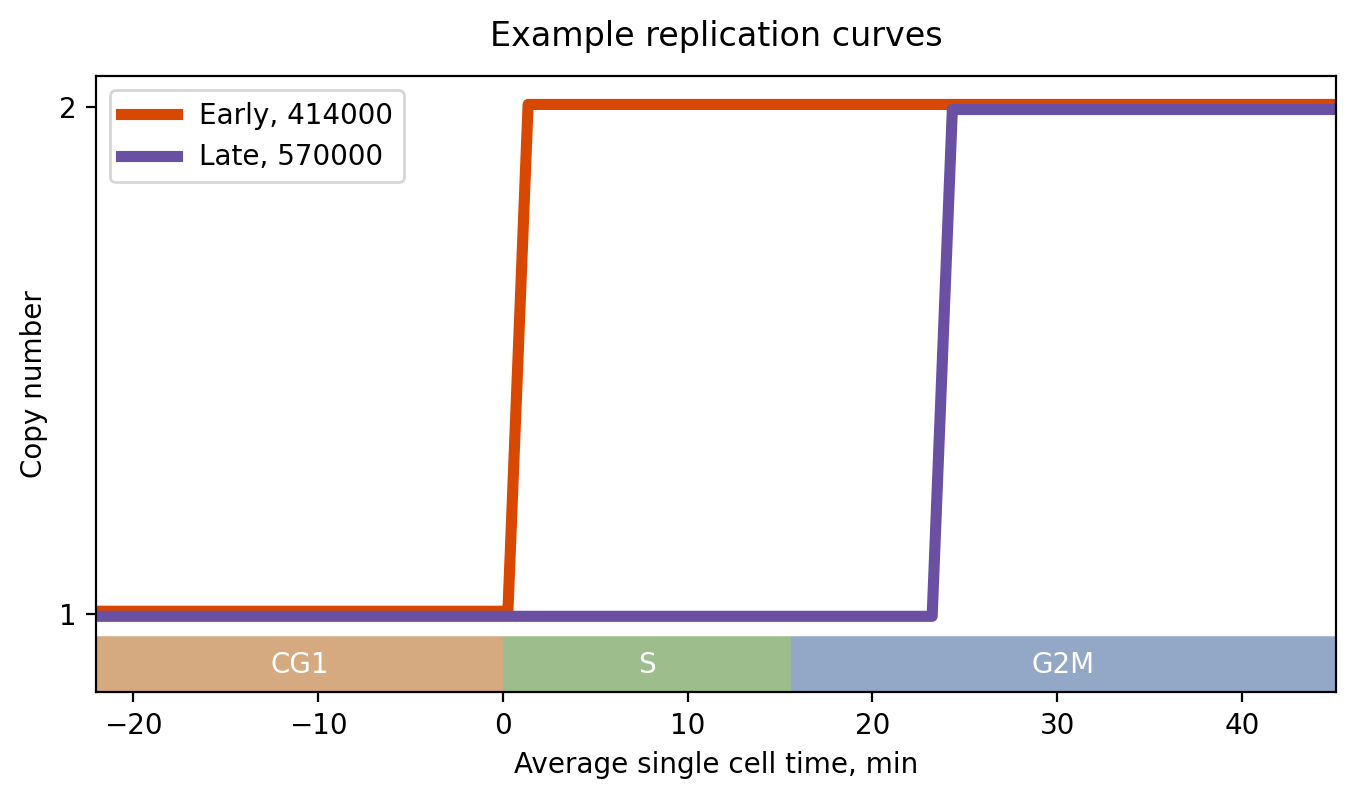

In [1127]:
deconv_test_g1_replication.plot_example_f_curves()
save_figure_for_paper("output/figures/Replication_Deconvolution/Example_deconv_curves.png")

In [ ]:
from src.RealDataReplication import early_color, late_color

deconv_test_g1_replication.plot_F()
plt.axvline(deconv_test_g1_replication.early_row.name, c=early_color, lw=1.5,
    label=f"Early, {deconv_test_g1_replication.early_row.name}")
plt.axvline(deconv_test_g1_replication.late_row.name, c=late_color, lw=1.5,
    label=f"Late, {deconv_test_g1_replication.late_row.name}")
plt.legend()

save_figure_for_paper('output/figures/Replication_Deconvolution/Replication_profile_chrom10_rep1.png')
